# Problem Statement

Business Context

Sales forecasting is the process of estimating future sales revenue using historical sales data, market trends, and current business conditions. Accurate sales forecasting enables organizations to make informed strategic and operational decisions by predicting future demand for products across different regions and outlets.

For retail businesses, reliable sales forecasts are critical for inventory planning, procurement, supply chain management, workforce allocation, budgeting, and regional sales strategy. Accurate forecasts help minimize stock shortages, reduce excess inventory, improve customer satisfaction, and optimize overall business performance. Additionally, forecasting establishes measurable benchmarks that enable businesses to monitor trends, evaluate performance, and proactively respond to changing market conditions.

SuperKart is a retail chain operating supermarkets and food marts across multiple Tier 1, Tier 2, and Tier 3 cities. The company offers a diverse range of consumer products, including groceries, beverages, dairy products, household items, health and hygiene products, and packaged foods. With stores varying in size, location, and customer demographics, sales performance differs significantly across products and outlets.

To improve inventory management and support data-driven regional planning, SuperKart aims to accurately forecast product sales revenue for its outlets for the upcoming quarter. Rather than relying solely on historical trends, the company seeks a predictive analytics solution capable of identifying the key factors influencing sales and generating reliable revenue forecasts.

To operationalize this solution across its retail network, SuperKart has partnered with a data science firm to develop an end-to-end machine learning pipeline. The solution will not only predict sales accurately but will also be deployed as a scalable application that can be integrated into the organization's decision-making systems, enabling business users to perform both single and batch sales predictions through an interactive interface.

Objective

The primary objective of this project is to build and deploy a robust machine learning regression model that accurately predicts the total sales revenue generated by products across SuperKart stores.

The project aims to:

* Analyze historical product and store data to identify the major factors influencing sales revenue.
* Perform comprehensive exploratory data analysis (EDA) to uncover meaningful business patterns and insights.
* Engineer relevant features that improve model performance while preserving business interpretability.
* Develop and compare multiple tree-based regression models to identify the best-performing forecasting solution.
* Optimize the selected model using hyperparameter tuning to improve predictive accuracy and generalization.
* Serialize the final model and deploy it using a Flask backend and Streamlit frontend, enabling both single-record and batch predictions.
* Provide actionable business recommendations that help SuperKart optimize inventory management, product assortment, shelf allocation, and regional sales strategies.

Data Description

The dataset contains product-level and store-level attributes that influence the total sales generated by each product within a specific SuperKart outlet. The variables included in the dataset are described below.

### Data Description

The dataset contains product-level and store-level attributes that influence the total sales generated by each product within a specific SuperKart outlet.

| **Feature** | **Description** |
|-------------|-----------------|
| **Product_Id** | Unique identifier assigned to each product. The identifier begins with two alphabetic characters followed by a numeric value. |
| **Product_Weight** | Weight of the product. |
| **Product_Sugar_Content** | Sugar content category of the product (e.g., Low Sugar, Regular, No Sugar). |
| **Product_Allocated_Area** | Ratio of the display area allocated to the product relative to the total display area in the store. |
| **Product_Type** | Broad product category such as Dairy, Meat, Frozen Foods, Soft Drinks, Household, Health & Hygiene, Seafood, Fruits & Vegetables, etc. |
| **Product_MRP** | Maximum Retail Price (MRP) of the product. |
| **Store_Id** | Unique identifier assigned to each retail outlet. |
| **Store_Establishment_Year** | Year in which the store was established. |
| **Store_Size** | Store size category (High, Medium, or Low). |
| **Store_Location_City_Type** | City classification (Tier 1, Tier 2, or Tier 3). |
| **Store_Type** | Type of retail outlet (Departmental Store, Supermarket Type 1, Supermarket Type 2, or Food Mart). |
| **Product_Store_Sales_Total** | **Target Variable:** Total sales revenue generated by a particular product in a specific store. |

# Import Libraries

In [83]:
# Install the required libraries
!pip install -q \
numpy==2.0.2 \
pandas==2.2.2 \
scikit-learn==1.6.1 \
matplotlib==3.10.0 \
seaborn==0.13.2 \
joblib==1.4.2 \
xgboost==2.1.4 \
requests==2.32.4 \
huggingface_hub==0.34.0

In [84]:
import warnings # Import the warnings module
warnings.filterwarnings("ignore") # Ignore all warnings to keep the output clean

In [85]:

# =============================================================================
# Data manipulation
# =============================================================================
import numpy as np # Import the numpy library for numerical operations
import pandas as pd # Import the pandas library for data manipulation and analysis

# =============================================================================
# Data visualization
# =============================================================================
import matplotlib.pyplot as plt # Import matplotlib for creating static, interactive, and animated visualizations
import seaborn as sns # Import seaborn for statistical data visualization

# =============================================================================
# Train-Test Split
# =============================================================================
from sklearn.model_selection import train_test_split # Import train_test_split for splitting data into training and testing sets

# =============================================================================
# Machine Learning Models
# =============================================================================
from sklearn.tree import DecisionTreeRegressor # Import DecisionTreeRegressor for decision tree regression models

from sklearn.ensemble import ( # Import ensemble models from scikit-learn
    BaggingRegressor, # BaggingRegressor for Bagging ensemble
    RandomForestRegressor, # RandomForestRegressor for Random Forest ensemble
    AdaBoostRegressor, # AdaBoostRegressor for AdaBoost ensemble
    GradientBoostingRegressor # GradientBoostingRegressor for Gradient Boosting ensemble
)

from xgboost import XGBRegressor # Import XGBRegressor for Extreme Gradient Boosting

# =============================================================================
# Model Evaluation Metrics
# =============================================================================
from sklearn.metrics import ( # Import metrics for evaluating regression models
    mean_squared_error, # Mean Squared Error
    mean_absolute_error, # Mean Absolute Error
    mean_absolute_percentage_error, # Mean Absolute Percentage Error
    r2_score # R-squared score
)

# =============================================================================
# Preprocessing and Pipelines
# =============================================================================
from sklearn.compose import make_column_transformer # Import make_column_transformer for applying different transformations to different columns
from sklearn.pipeline import Pipeline # Import Pipeline for chaining multiple processing steps
from sklearn.preprocessing import OneHotEncoder # Import OneHotEncoder for one-hot encoding categorical features

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
# =============================================================================
# Hyperparameter Tuning
# =============================================================================
from sklearn.model_selection import GridSearchCV # Import GridSearchCV for exhaustive search over specified parameter values for an estimator

# =============================================================================
# Model Serialization
# =============================================================================
import joblib # Import joblib for saving and loading Python objects

# =============================================================================
# Operating System Utilities
# =============================================================================
import os # Import the os module for interacting with the operating system

# =============================================================================
# API Requests
# =============================================================================
import requests # Import the requests library for making HTTP requests

# =============================================================================
# Hugging Face Authentication
# =============================================================================
from huggingface_hub import login, HfApi # Import login and HfApi for Hugging Face Hub interaction

# =============================================================================
# Display Settings
# =============================================================================
pd.set_option("display.max_columns", None) # Set pandas option to display all columns
pd.set_option("display.max_rows", 100) # Set pandas option to display up to 100 rows

# =============================================================================
# Notebook Settings
# =============================================================================
sns.set_style("whitegrid") # Set the seaborn style to 'whitegrid'
plt.rcParams["figure.figsize"] = (10, 6) # Set the default figure size for matplotlib plots

# Loading the Dataset

In [86]:
# =============================================================================
# Load the dataset
# =============================================================================

# Read the SuperKart dataset from Google Drive into a pandas DataFrame
kart = pd.read_csv("/content/SuperKart.csv")

# Display the first five rows of the DataFrame
kart.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


The dataset has been successfully loaded into a pandas DataFrame named `kart`. The first five rows show a mix of numerical and categorical features related to products and stores, along with the target variable `Product_Store_Sales_Total`.

In [87]:
# =============================================================================
# Create a working copy of the dataset
# =============================================================================

# Create a copy of the original dataset to preserve the raw data
data = kart.copy()

# Verify the dataset shape (number of rows and columns)
print(f"Dataset Shape: {data.shape}")

# Display the first five rows of the copied DataFrame
data.head()

Dataset Shape: (8763, 12)


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


A working copy of the dataset named `data` has been created. The dataset contains 8763 rows and 12 columns, and its first five rows are displayed, confirming the copy operation.

# Data Overview

In [88]:
# =============================================================================
# Display the first five rows of the dataset
# =============================================================================

data.head() # Display the first five rows of the DataFrame

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


The `head()` method confirms the successful loading and copying of the dataset, displaying the first five entries and their respective columns.

In [89]:
# =============================================================================
# Display five random observations from the dataset
# =============================================================================

data.sample(5, random_state=42) # Display 5 random rows from the DataFrame, ensuring reproducibility with random_state

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
1226,FD1781,12.53,Regular,0.066,Snack Foods,145.62,OUT004,2009,Medium,Tier 2,Supermarket Type2,3396.37
7903,FD3171,13.29,Low Sugar,0.086,Canned,135.99,OUT004,2009,Medium,Tier 2,Supermarket Type2,3371.45
1559,FD1479,9.99,Regular,0.090,Fruits and Vegetables,125.79,OUT001,1987,High,Tier 2,Supermarket Type1,2416.69
3621,NC4402,10.72,No Sugar,0.049,Health and Hygiene,92.94,OUT002,1998,Small,Tier 3,Food Mart,1910.53
7552,DR433,15.60,Low Sugar,0.121,Soft Drinks,176.07,OUT001,1987,High,Tier 2,Supermarket Type1,3191.08


Displaying five random observations helps to get a broader sense of the data's variability and content beyond just the top or bottom rows.

In [90]:
# =============================================================================
# Display the last five rows of the dataset
# =============================================================================

data.tail() # Display the last five rows of the DataFrame

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


The `tail()` method shows the last five rows of the dataset, providing another quick check of the data's structure and content.

In [91]:
data.shape # Get the shape (number of rows, number of columns) of the DataFrame

(8763, 12)

The dataset has a shape of (8763, 12), indicating 8763 rows (observations) and 12 columns (features).

In [92]:
data.info() # Display a concise summary of the DataFrame, including data types and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


The `info()` output reveals that the dataset contains 12 columns. All columns have 8763 non-null entries, which means there are no missing values in this dataset. The data types include 4 float64, 1 int64, and 7 object (categorical) columns.

In [93]:
# =============================================================================
# Explore Product_Id
# =============================================================================

print("Number of unique Product IDs:", data["Product_Id"].nunique()) # Print the number of unique product IDs

print("\nProduct Family Distribution:") # Print a header for product family distribution
display(data["Product_Id"].str[:2].value_counts()) # Display the value counts of product families (first two characters of Product_Id)

Number of unique Product IDs: 8763

Product Family Distribution:


,count
Product_Id,
FD,6539
NC,1519
DR,705


The `Product_Id` column has 8763 unique values, indicating that each product in the dataset is unique. The `Product Family Distribution` shows the frequency of different product categories based on the first two characters of the `Product_Id`, with 'FD' (Food) being the most common, followed by 'NC' (Non-Consumable) and 'DR' (Drinks).

In [94]:
# =============================================================================
# Convert object columns into category datatype
# =============================================================================

# Iterate through columns identified as 'object' (string) type
for column in data.select_dtypes(include="object").columns:
    data[column] = data[column].astype("category") # Convert the column's data type to 'category'

All object-type columns (`Product_Id`, `Product_Sugar_Content`, `Product_Type`, `Store_Id`, `Store_Size`, `Store_Location_City_Type`, `Store_Type`) have been successfully converted to the `category` data type, which is memory-efficient and suitable for categorical features.

In [95]:
# =============================================================================
# Display value counts for categorical features
# =============================================================================

# Iterate through columns identified as 'category' type
for column in data.select_dtypes(include="category").columns:
    print("=" * 60) # Print a separator line
    print(f"{column}") # Print the current column name
    print("=" * 60) # Print another separator line
    display(data[column].value_counts()) # Display the frequency of each unique value in the column

Product_Id


,count
Product_Id,
NC993,1
DR1005,1
DR1006,1
DR1011,1
DR1045,1
...,...
DR1204,1
DR12,1
DR1185,1


Product_Sugar_Content


,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2251
No Sugar,1519
reg,108


Product_Type


...

,count
Store_Size,
Medium,6025
High,1586
Small,1152


Store_Location_City_Type


,count
Store_Location_City_Type,
Tier 2,6262
Tier 1,1349
Tier 3,1152


Store_Type


,count
Store_Type,
Supermarket Type2,4676
Supermarket Type1,1586
Departmental Store,1349
Food Mart,1152


The value counts for each categorical feature (e.g., `Product_Id`, `Product_Sugar_Content`, `Product_Type`, `Store_Id`, `Store_Size`, `Store_Location_City_Type`, `Store_Type`) have been displayed. This provides insight into the distribution and cardinality of categories within each feature, confirming `Product_Id` is unique for each entry, 'Low Sugar' is the most frequent `Product_Sugar_Content`, 'Fruits and Vegetables' is the most common `Product_Type`, 'OUT004' is the most frequent `Store_Id`, 'Medium' is the most common `Store_Size`, 'Tier 2' is the most frequent `Store_Location_City_Type`, and 'Supermarket Type2' is the most common `Store_Type`.

In [96]:
# =============================================================================
# Summary statistics for numerical features
# =============================================================================

data.describe().T # Display descriptive statistics for numerical columns, transposed for better readability

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


The summary statistics for numerical features (`Product_Weight`, `Product_Allocated_Area`, `Product_MRP`, `Store_Establishment_Year`, `Product_Store_Sales_Total`) provide key metrics like mean, standard deviation, min, max, and quartiles. This helps understand the distribution and potential outliers in these continuous variables. For instance, `Product_MRP` ranges from 31 to 266, and `Product_Store_Sales_Total` ranges from 33 to 8000.

In [97]:
# =============================================================================
# Summary statistics for categorical variables
# =============================================================================

data.describe(include="category").T # Display descriptive statistics for categorical columns, transposed for better readability

,count,unique,top,freq
Product_Id,8763,8763,NC993,1
Product_Sugar_Content,8763,4,Low Sugar,4885
Product_Type,8763,16,Fruits and Vegetables,1249
Store_Id,8763,4,OUT004,4676
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676


The summary statistics for categorical variables (`Product_Id`, `Product_Sugar_Content`, `Product_Type`, `Store_Id`, `Store_Size`, `Store_Location_City_Type`, `Store_Type`) show the count of non-null entries, number of unique categories, the most frequent category (`top`), and its frequency (`freq`). This confirms `Product_Id` has 8763 unique values, and highlights the dominant categories in other features.

In [98]:
# =============================================================================
# Check duplicate records
# =============================================================================

print("Number of duplicate rows:", data.duplicated().sum()) # Print the total count of duplicate rows in the DataFrame

Number of duplicate rows: 0


The output confirms that there are `0` duplicate rows in the dataset, indicating that all observations are unique.

In [99]:
# =============================================================================
# Check missing values
# =============================================================================

data.isnull().sum() # Calculate and display the sum of null values for each column

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


The output of `data.isnull().sum()` shows that there are no missing values (`0` for all columns) in the dataset, which simplifies the data preprocessing step by eliminating the need for imputation.

# Exploratory Data Analysis (EDA)

## Univariate Analysis

In [100]:
# Function to plot histogram and boxplot together
# Used for numerical variables

def histogram_boxplot(data, feature, figsize=(12,7), kde=False, bins=None): # Define a function to create a histogram and boxplot for a numerical feature

    fig, (ax_box, ax_hist) = plt.subplots( # Create a figure and a set of subplots
        nrows=2, # Specify 2 rows for the subplots
        sharex=True, # Share the x-axis between the subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)}, # Set the height ratios for the subplots
        figsize=figsize # Set the figure size
    )

    sns.boxplot( # Create a boxplot
        data=data, # Use the provided DataFrame
        x=feature, # Plot the specified feature on the x-axis
        ax=ax_box, # Place the boxplot in the top subplot
        showmeans=True, # Show the mean on the boxplot
        color="turquoise" # Set the color of the boxplot
    )

    if bins: # Check if bins are specified
        sns.histplot( # Create a histogram
            data=data, # Use the provided DataFrame
            x=feature, # Plot the specified feature on the x-axis
            bins=bins, # Use the specified number of bins
            kde=kde, # Plot kernel density estimate if kde is True
            ax=ax_hist # Place the histogram in the bottom subplot
        )
    else: # If bins are not specified
        sns.histplot( # Create a histogram
            data=data, # Use the provided DataFrame
            x=feature, # Plot the specified feature on the x-axis
            kde=kde, # Plot kernel density estimate if kde is True
            ax=ax_hist # Place the histogram in the bottom subplot
        )

    ax_hist.axvline( # Add a vertical line for the mean
        data[feature].mean(), # Position the line at the mean of the feature
        color="green", # Set the line color to green
        linestyle="--", # Set the line style to dashed
        label="Mean" # Label the line as 'Mean'
    )

    ax_hist.axvline( # Add a vertical line for the median
        data[feature].median(), # Position the line at the median of the feature
        color="black", # Set the line color to black
        linestyle="-", # Set the line style to solid
        label="Median" # Label the line as 'Median'
    )

    ax_hist.legend() # Display the legend

    plt.show() # Show the plot

In [101]:
# Function for plotting categorical variables

def labeled_barplot(data, feature, perc=False, n=None): # Define a function to create a labeled bar plot for a categorical feature

    total = len(data[feature]) # Calculate the total number of observations for the feature
    count = data[feature].nunique() # Calculate the number of unique categories in the feature

    plt.figure(figsize=(count+1,5) if n is None else (n+1,5)) # Create a figure with a dynamic size based on the number of unique categories or a specified 'n'

    ax = sns.countplot( # Create a count plot (bar plot)
        data=data, # Use the provided DataFrame
        x=feature, # Plot the specified feature on the x-axis
        order=data[feature].value_counts().index[:n].sort_values(), # Order the bars by value counts (top 'n' or all) in ascending order
        palette="Paired" # Set the color palette for the bars
    )

    plt.xticks(rotation=90, fontsize=12) # Rotate x-axis labels for better readability and set font size

    for p in ax.patches: # Iterate over the bars (patches) in the plot

        if perc: # Check if percentage should be displayed
            label = "{:.1f}%".format(100*p.get_height()/total) # Format label as percentage
        else: # If not percentage, display count
            label = p.get_height() # Get the height of the bar (count)

        x = p.get_x() + p.get_width()/2 # Calculate x-position for the label (center of the bar)
        y = p.get_height() # Get y-position for the label (top of the bar)

        ax.annotate( # Add text annotation (label) to the bar
            label, # The text label to display
            (x,y), # The (x,y) coordinates for the label
            ha="center", # Horizontal alignment to center
            va="center", # Vertical alignment to center
            xytext=(0,5), # Offset the text slightly above the bar
            textcoords="offset points", # Interpret xytext as offset points
            fontsize=11 # Set the font size of the label
        )

    plt.show() # Show the plot

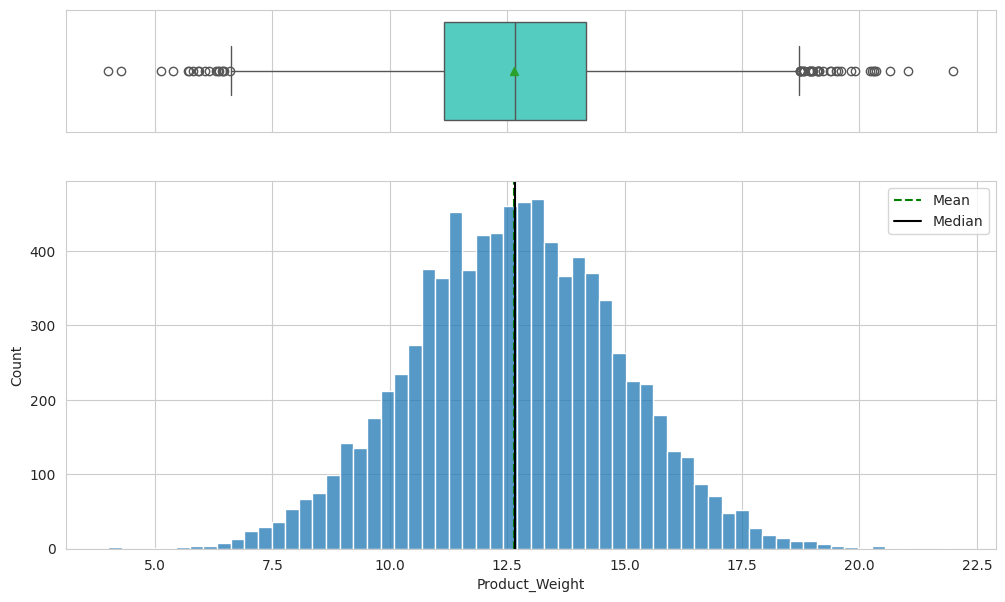

In [102]:
histogram_boxplot(data,"Product_Weight") # Call the custom function to plot histogram and boxplot for 'Product_Weight'

The `Product_Weight` distribution is unimodal and roughly symmetrical, centered around 12-13. The boxplot indicates a few outliers on both the lower and higher ends, but the majority of the data lies within a consistent range.

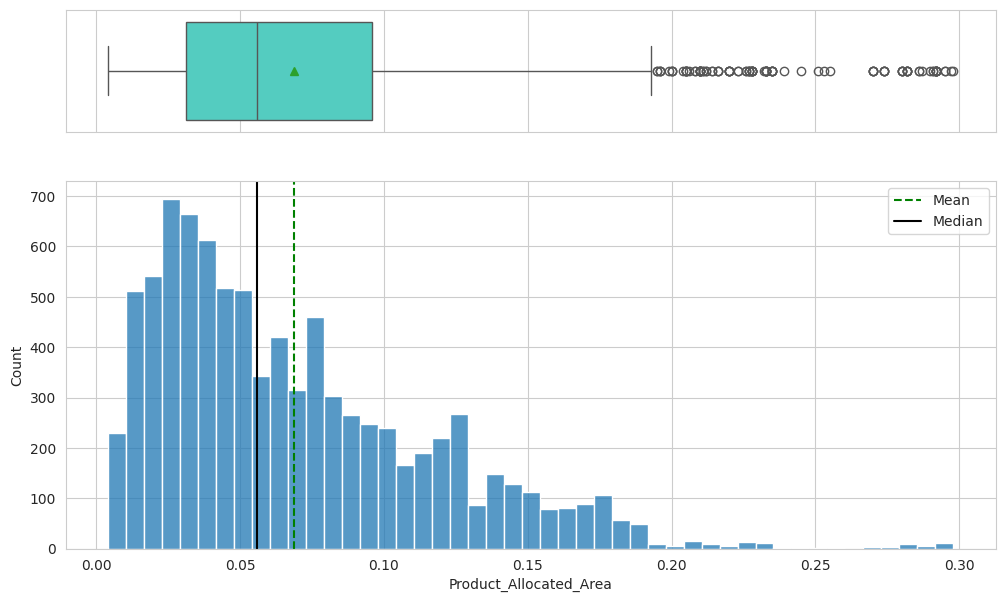

In [103]:
histogram_boxplot(data, "Product_Allocated_Area") # Call the custom function to plot histogram and boxplot for 'Product_Allocated_Area'

The `Product_Allocated_Area` distribution is positively skewed, with a majority of products having smaller allocated areas. There are several outliers with unusually high allocated areas, as shown by the boxplot.

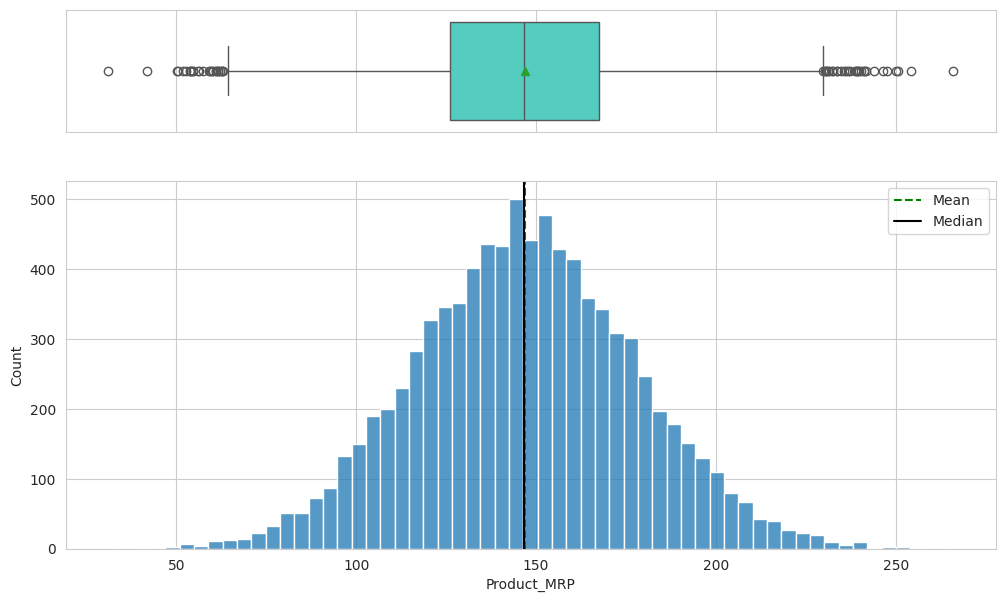

In [104]:
histogram_boxplot(data, "Product_MRP") # Call the custom function to plot histogram and boxplot for 'Product_MRP'

The `Product_MRP` (Maximum Retail Price) distribution appears relatively symmetrical and unimodal, centered around 140-150. There are some outliers on both the lower and higher ends of the MRP scale.

In [105]:
print(data["Store_Establishment_Year"].unique()) # Print the unique values present in the 'Store_Establishment_Year' column

[2009 1999 1987 1998]


The unique `Store_Establishment_Year` values are 2009, 1999, 1987, and 1998, indicating that stores were established in these specific years.

In [106]:
display(data["Store_Establishment_Year"].describe()) # Display descriptive statistics for 'Store_Establishment_Year'

,Store_Establishment_Year
count,8763.000000
mean,2002.032751
std,8.388381
min,1987.000000
25%,1998.000000
50%,2009.000000
75%,2009.000000
max,2009.000000


The descriptive statistics for `Store_Establishment_Year` show a mean of approximately 2002, with stores established between 1987 and 2009. The 25th percentile is 1998, the median is 2009, and the 75th percentile is also 2009, suggesting a concentration of newer stores established around 2009, and a smaller number of older stores.

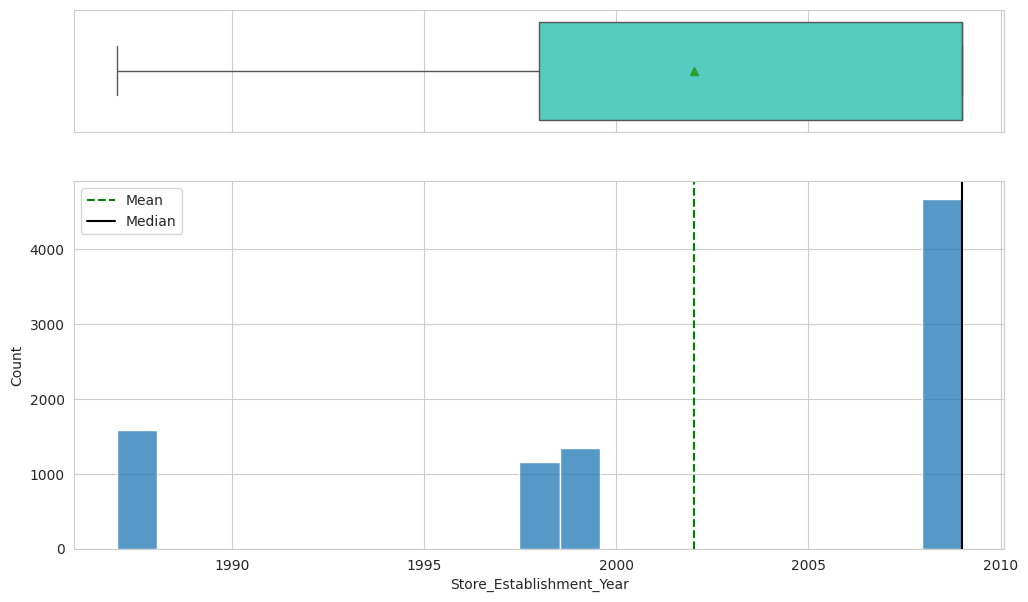

In [107]:

histogram_boxplot(data, "Store_Establishment_Year") # Call the custom function to plot histogram and boxplot for 'Store_Establishment_Year'

The histogram and boxplot for `Store_Establishment_Year` clearly show that stores were established in specific years: 1987, 1998, 1999, and 2009. The largest number of stores were established in 2009, followed by 1987. The mean and median are both closer to 2009, reflecting the higher concentration of stores established in that year.

## Bivariate Analysis

Objective

The target variable, Product_Store_Sales_Total, is continuous in nature, making this a regression problem. In this section, relationships between the target variable and predictor variables are explored to understand the major factors influencing product sales across SuperKart stores.

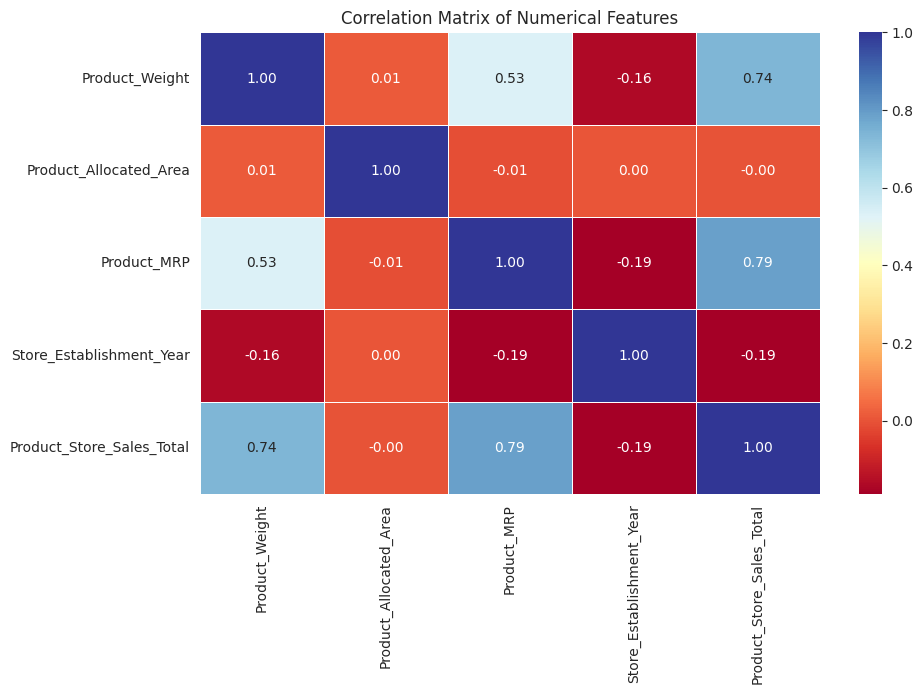

In [108]:
# =============================================================================
# Correlation matrix for numerical features
# =============================================================================

# Select only numerical columns from the DataFrame for correlation analysis
numeric_features = data.select_dtypes(include=["number"])

# Calculate the pairwise correlation between numerical columns
corr_matrix = numeric_features.corr()

# Create a figure for the heatmap with a specified size
plt.figure(figsize=(10,6))

# Generate a heatmap to visualize the correlation matrix
sns.heatmap(
    corr_matrix, # The correlation matrix to plot
    annot=True, # Display the correlation values on the heatmap cells
    cmap="RdYlBu", # Choose a colormap to represent correlation strength and direction
    fmt=".2f", # Format the annotation text to two decimal places
    linewidths=0.5 # Add lines between cells for better visual separation
)

# Set the title of the plot
plt.title("Correlation Matrix of Numerical Features")

# Display the plot
plt.show()

The correlation matrix displays the pairwise correlation coefficients between numerical features. `Product_Store_Sales_Total` shows a strong positive correlation with `Product_MRP` (0.79) and `Product_Weight` (0.74). There's a weaker correlation with `Product_Allocated_Area` (0.01) and a negative correlation with `Store_Establishment_Year` (-0.19), suggesting older stores or stores established in earlier years tend to have slightly lower sales. `Product_MRP` and `Product_Weight` also show a moderate positive correlation (0.53).

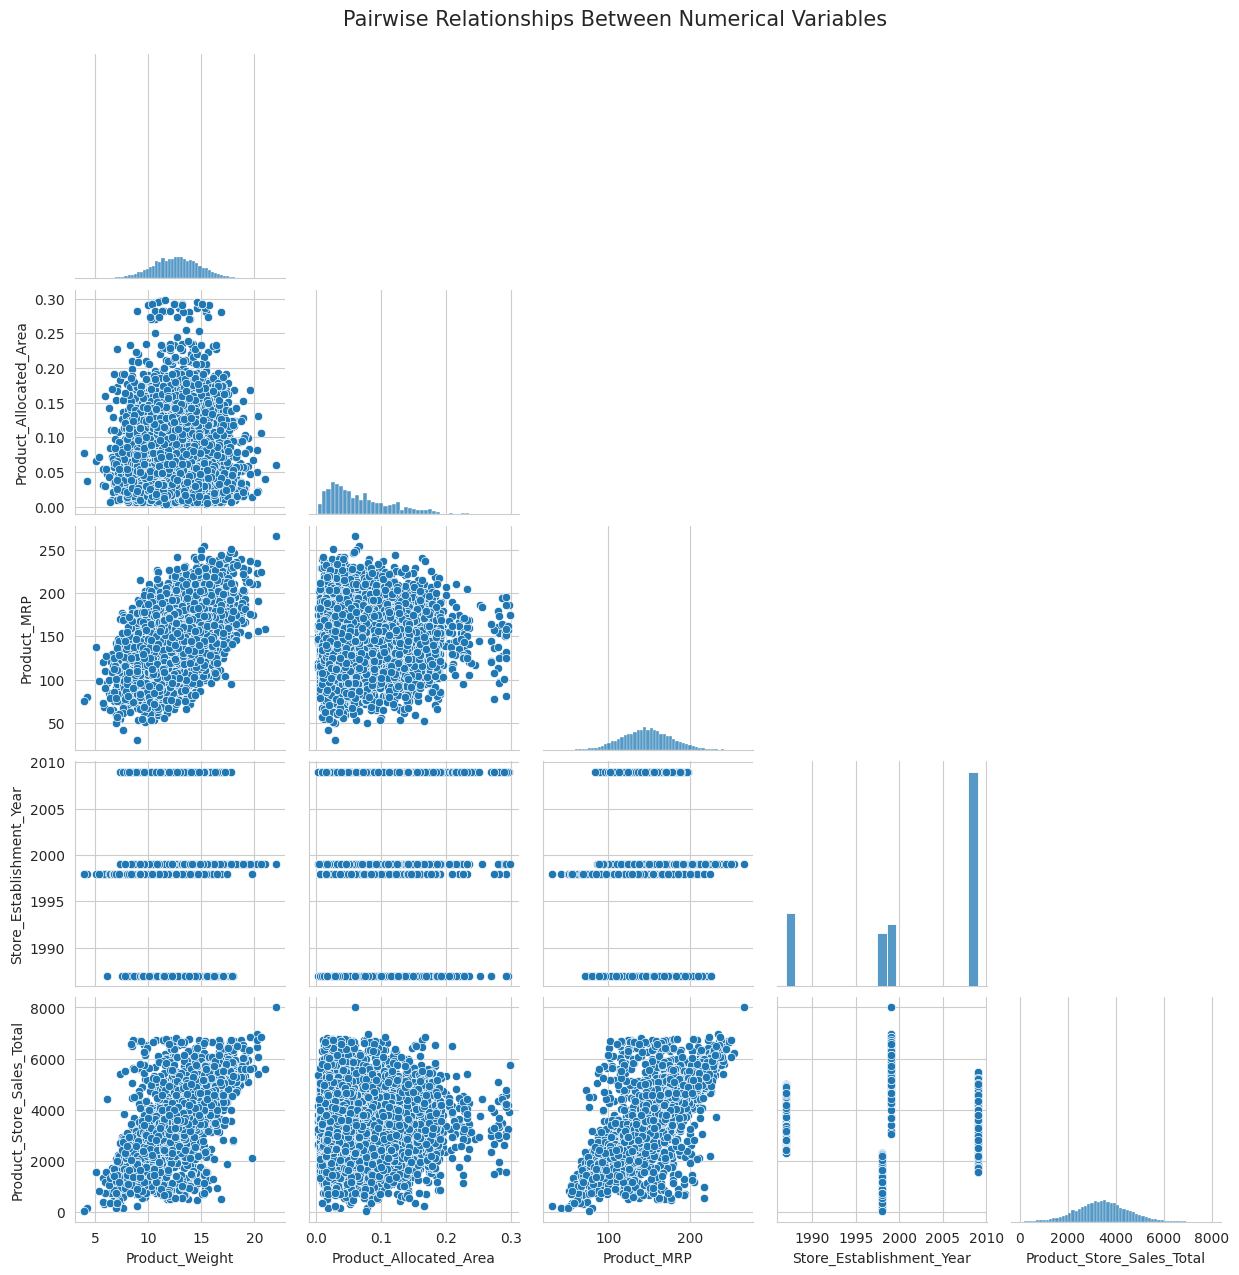

In [109]:
# =============================================================================
# Pairwise relationships between numerical variables
# =============================================================================

# Create a pairplot to visualize pairwise relationships and distributions
sns.pairplot(
    data=numeric_features, # Use the DataFrame containing only numerical features
    diag_kind="hist", # Show histograms on the diagonal plots to represent univariate distributions
    corner=True # Only plot the lower triangle of the pairplot, as it's symmetric
)

# Set a suptitle for the entire pairplot
plt.suptitle(
    "Pairwise Relationships Between Numerical Variables",
    y=1.02, # Adjust the vertical position of the suptitle
    fontsize=15 # Set the font size of the suptitle
)

# Display the plot
plt.show()

The pairplot visualizes the pairwise relationships between all numerical variables, including their distributions. It confirms the observations from the correlation matrix: `Product_Store_Sales_Total` generally increases with `Product_MRP` and `Product_Weight`. The histograms on the diagonal show the distributions of individual variables. For `Product_MRP` and `Product_Weight`, the plots against `Product_Store_Sales_Total` suggest a positive trend, but with significant spread, indicating other factors influence sales. The distribution of `Store_Establishment_Year` is clearly discrete, as expected.

In [110]:
# =============================================================================
# Function to summarize and visualize revenue by categorical feature
# =============================================================================

def revenue_summary(df, feature):

    # Group the DataFrame by the specified feature, calculate the sum of 'Product_Store_Sales_Total',
    # sort in descending order, and reset the index to turn the Series into a DataFrame
    revenue = (
        df.groupby(feature)["Product_Store_Sales_Total"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )

    # Display the summary DataFrame
    display(revenue)

    # Create a figure for the bar plot with a specified size
    plt.figure(figsize=(9,5))

    # Create a bar plot to visualize total revenue by the specified feature
    sns.barplot(
        data=revenue, # Use the aggregated revenue DataFrame
        x=feature, # Plot the categorical feature on the x-axis
        y="Product_Store_Sales_Total" # Plot total sales revenue on the y-axis
    )

    # Rotate x-axis labels for better readability, especially if there are many categories
    plt.xticks(rotation=45)

    # Set the y-axis label
    plt.ylabel("Total Revenue")

    # Set the x-axis label, replacing underscores with spaces for readability
    plt.xlabel(feature.replace("_"," "))

    # Set the title of the plot
    plt.title(f"Revenue by {feature.replace('_',' ')}")

    # Display the plot
    plt.show()

,Product_Type,Product_Store_Sales_Total
0,Fruits and Vegetables,4300833.27
1,Snack Foods,3988996.95
2,Dairy,2811918.04
3,Frozen Foods,2809980.83
4,Household,2564740.17
5,Baking Goods,2452986.00
6,Canned,2300082.71
7,Health and Hygiene,2163707.21
8,Meat,2129211.94
9,Soft Drinks,1797044.72


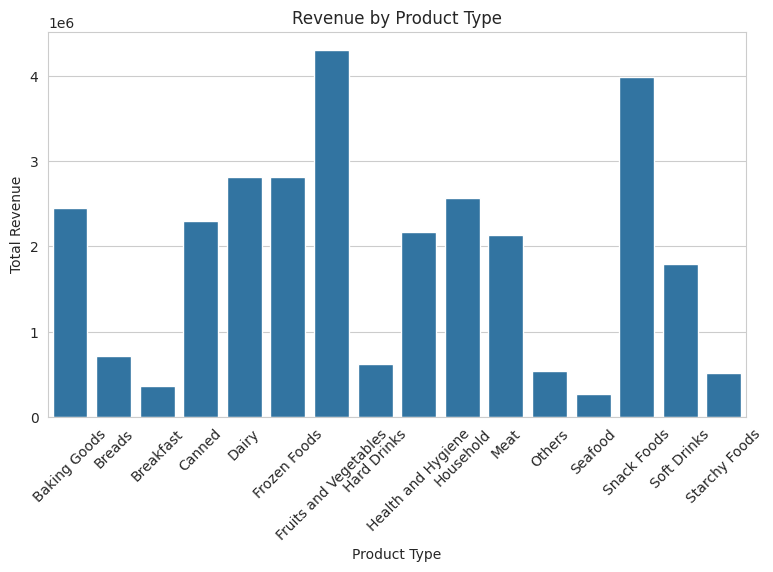

In [111]:
# =============================================================================
# Analyze total revenue by Product_Type
# =============================================================================

# Call the custom function to summarize and plot total revenue for each Product_Type
revenue_summary(data,"Product_Type")

The bar plot displays the total revenue generated by each `Product_Type`. 'Frozen Foods' and 'Snack Foods' are the top revenue-generating product types, significantly outperforming others. 'Baking Goods' also contribute substantial revenue. 'Hard Drinks', 'Breakfast', and 'Starchy Foods' generate relatively lower revenue. This highlights the varying sales performance across different product categories, which is crucial for inventory and marketing strategies.

,Product_Sugar_Content,Product_Store_Sales_Total
0,Low Sugar,16823405.80
1,Regular,7867671.29
2,No Sugar,5269943.68
3,reg,394043.13


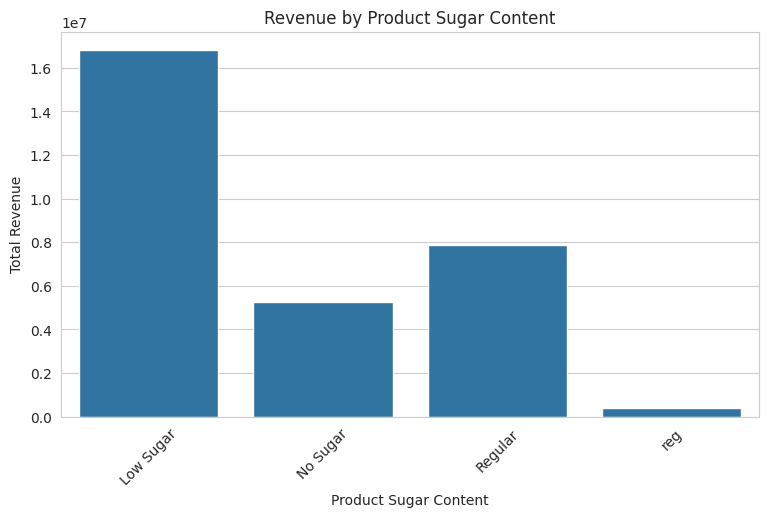

In [112]:
# =============================================================================
# Analyze total revenue by Product_Sugar_Content
# =============================================================================

# Call the custom function to summarize and plot total revenue for each Product_Sugar_Content category
revenue_summary(data,"Product_Sugar_Content")

This bar plot illustrates the total revenue generated by products based on their `Product_Sugar_Content`. 'Low Sugar' products contribute the highest total revenue, followed by 'Regular' sugar content products. 'No Sugar' products generate moderate revenue, while the 'reg' category shows the lowest revenue. This indicates a strong preference or higher sales volume for low-sugar options, which can inform product development and promotion strategies.

,Store_Id,Product_Store_Sales_Total
0,OUT004,15427583.43
1,OUT003,6673457.57
2,OUT001,6223113.18
3,OUT002,2030909.72


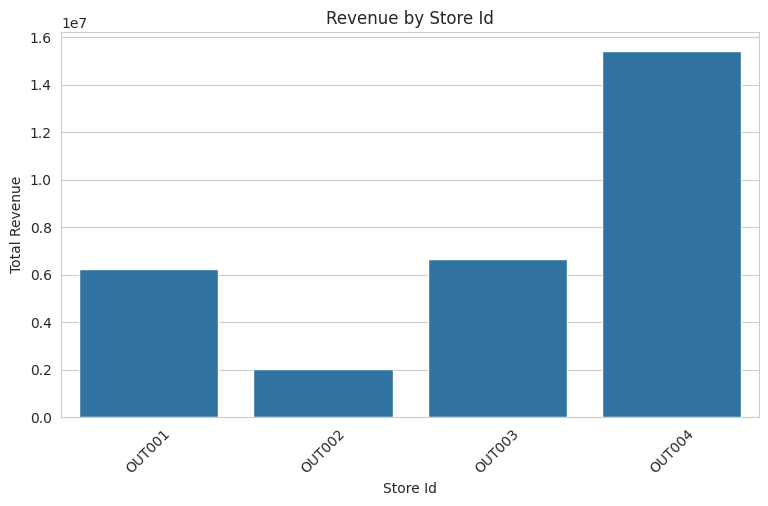

In [113]:
# =============================================================================
# Analyze total revenue by Store_Id
# =============================================================================

# Call the custom function to summarize and plot total revenue for each Store_Id
revenue_summary(data,"Store_Id")

The bar plot shows the total revenue generated by each `Store_Id`. `OUT004` stands out as the highest revenue-generating store, with significantly higher sales than the other stores. `OUT001` and `OUT003` have similar and moderate revenue contributions, while `OUT002` generates the least revenue. This suggests substantial differences in store performance, likely influenced by factors such as store location, size, or type.

,Store_Type,Product_Store_Sales_Total
0,Supermarket Type2,15427583.43
1,Departmental Store,6673457.57
2,Supermarket Type1,6223113.18
3,Food Mart,2030909.72


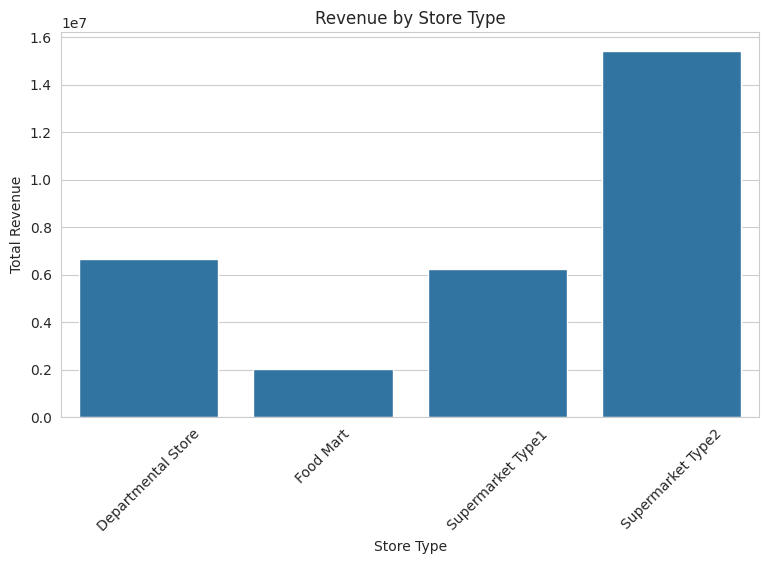

In [114]:
# =============================================================================
# Analyze total revenue by Store_Type
# =============================================================================

# Call the custom function to summarize and plot total revenue for each Store_Type
revenue_summary(data,"Store_Type")

This bar plot illustrates the total revenue generated by each `Store_Type`. 'Supermarket Type2' is the highest revenue-generating store type, closely followed by 'Supermarket Type1'. 'Departmental Store' also contributes a notable amount of revenue, while 'Food Mart' generates the least. This indicates that supermarket formats, especially 'Supermarket Type2', are the most successful in terms of total sales.

,Store_Size,Product_Store_Sales_Total
0,Medium,22101041.00
1,High,6223113.18
2,Small,2030909.72


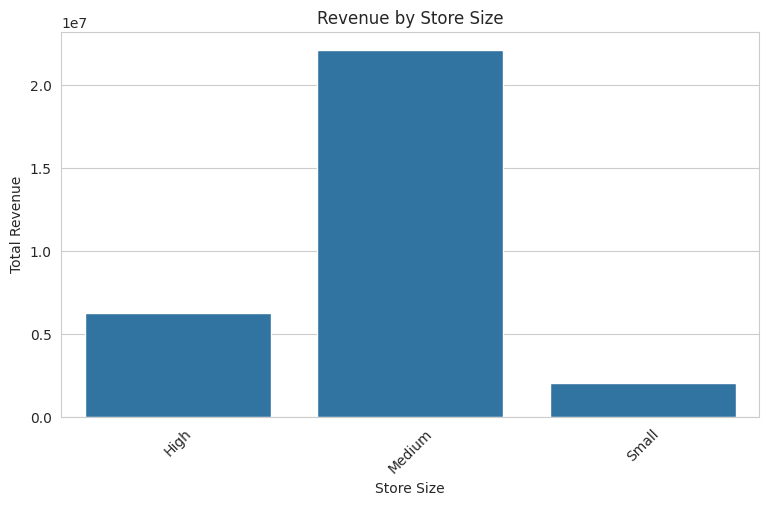

In [115]:
# =============================================================================
# Analyze total revenue by Store_Size
# =============================================================================

# Call the custom function to summarize and plot total revenue for each Store_Size
revenue_summary(data,"Store_Size")

The bar plot displays the total revenue generated by `Store_Size`. 'Medium' sized stores are the highest revenue contributors by a significant margin. 'High' sized stores contribute a moderate amount, while 'Small' sized stores generate the least revenue. This suggests that medium-sized stores are optimal for revenue generation in the SuperKart chain, potentially balancing capacity with operational efficiency and customer reach.

,Store_Location_City_Type,Product_Store_Sales_Total
0,Tier 2,21650696.61
1,Tier 1,6673457.57
2,Tier 3,2030909.72


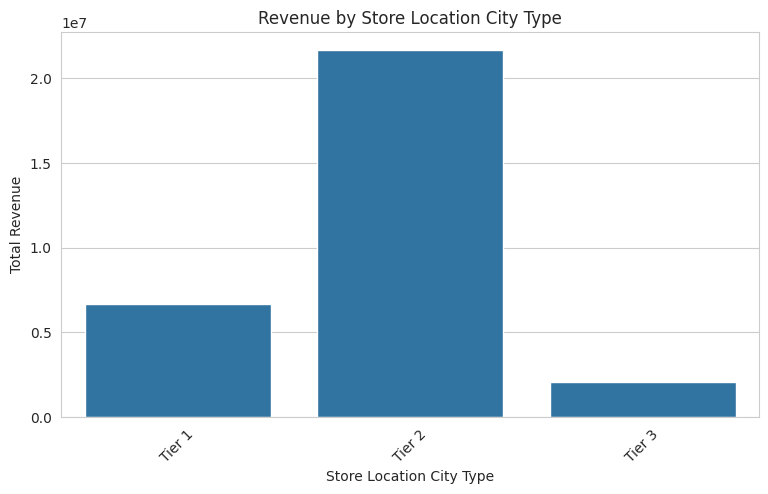

In [116]:
# =============================================================================
# Analyze total revenue by Store_Location_City_Type
# =============================================================================

# Call the custom function to summarize and plot total revenue for each Store_Location_City_Type
revenue_summary(data,"Store_Location_City_Type")

The bar plot shows the total revenue generated based on `Store_Location_City_Type`. 'Tier 2' cities generate the highest total revenue, followed by 'Tier 1' cities, and 'Tier 3' cities contribute the least. This indicates that stores in Tier 2 cities are particularly successful in terms of sales, potentially due to a good balance of population density, consumer purchasing power, and competition.

In [117]:
# =============================================================================
# Function to create a boxplot of target variable across categorical features
# =============================================================================

def category_boxplot(df, feature, target="Product_Store_Sales_Total"):

    # Create a figure for the boxplot with a specified size
    plt.figure(figsize=(12,6))

    # Create a boxplot to visualize the distribution of the target variable
    # across different categories of the specified feature
    sns.boxplot(
        data=df, # Use the provided DataFrame
        x=feature, # Plot the categorical feature on the x-axis
        y=target # Plot the target variable (sales) on the y-axis
    )

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

    # Set the title of the plot
    plt.title(f"{target} across {feature}")

    # Display the plot
    plt.show()

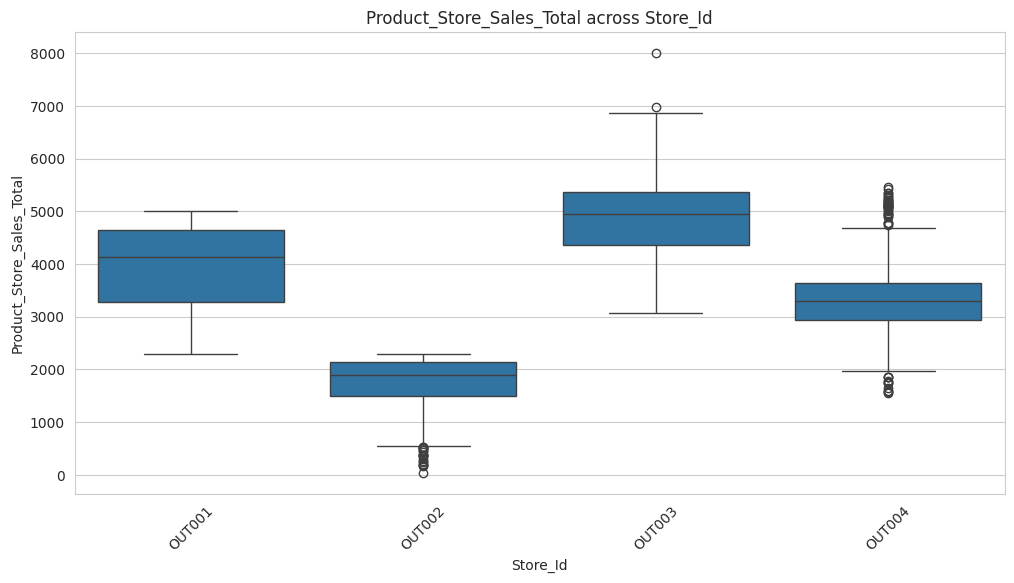

In [118]:
# =============================================================================
# Visualize Product_Store_Sales_Total across Store_Id
# =============================================================================

# Call the custom function to generate a boxplot of sales distribution for each Store_Id
category_boxplot(data,"Store_Id")

The boxplot shows the distribution of `Product_Store_Sales_Total` across different `Store_Id`s. `OUT003` and `OUT001` exhibit higher median sales and wider distributions, indicating generally higher sales and more variability. `OUT004` has a moderate median but a narrower spread. `OUT002` consistently shows the lowest median sales and a very tight distribution, suggesting lower and less variable sales. Outliers are present in all store types, particularly in `OUT003`.

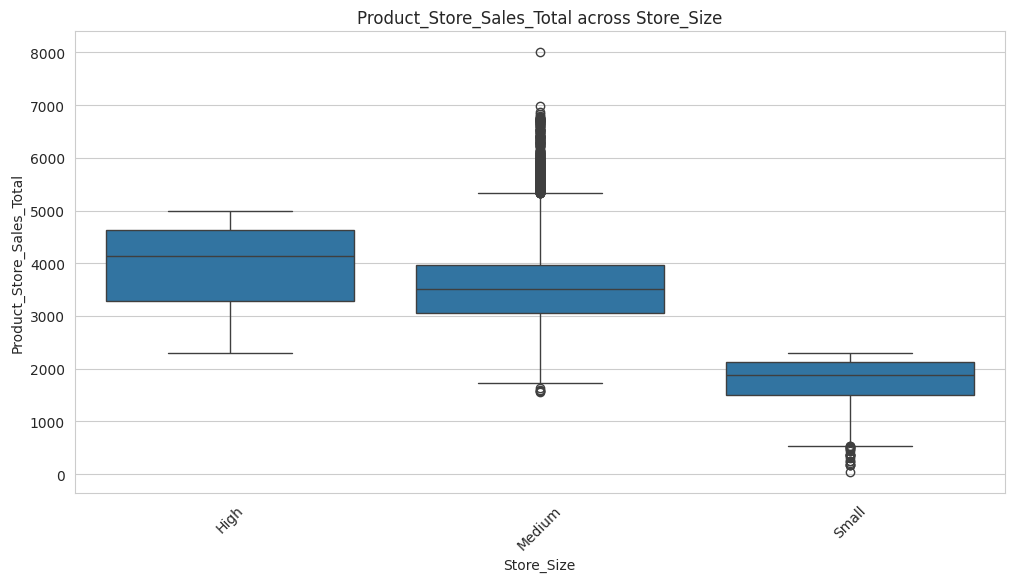

In [119]:
# =============================================================================
# Visualize Product_Store_Sales_Total across Store_Size
# =============================================================================

# Call the custom function to generate a boxplot of sales distribution for each Store_Size
category_boxplot(data,"Store_Size")

The boxplot illustrates the distribution of `Product_Store_Sales_Total` across different `Store_Size` categories. 'High' sized stores generally have the highest median sales and a substantial range. 'Medium' sized stores also show a wide distribution and a good median, but with many outliers towards higher sales. 'Small' sized stores have the lowest median sales and a narrower distribution, indicating consistently lower sales. This reinforces that larger stores tend to achieve higher sales, although medium stores can also have high-performing products.

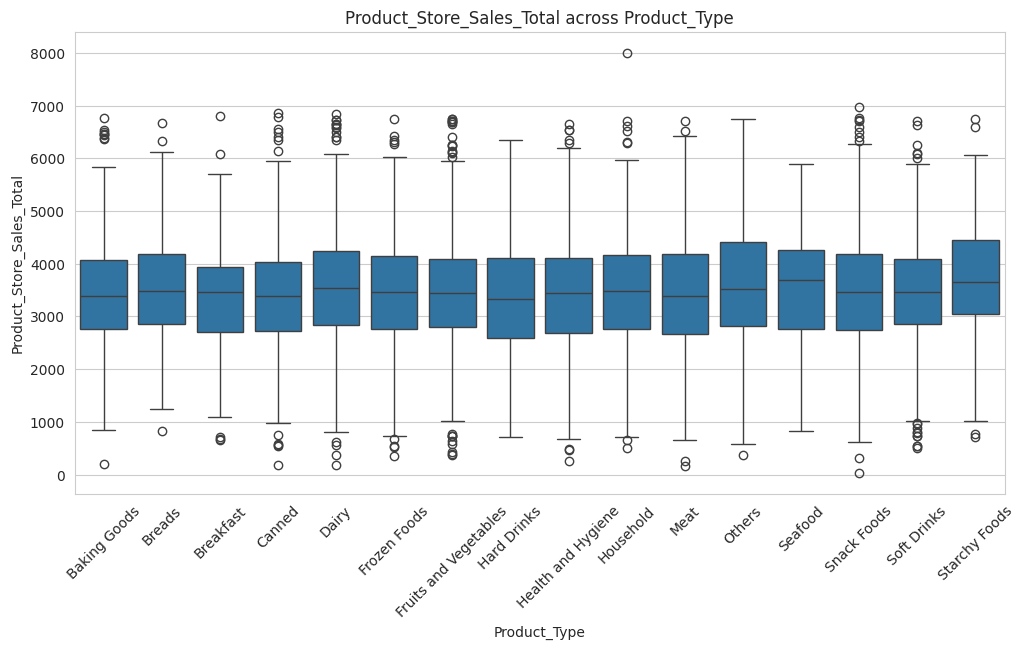

In [120]:
# =============================================================================
# Visualize Product_Store_Sales_Total across Product_Type
# =============================================================================

# Call the custom function to generate a boxplot of sales distribution for each Product_Type
category_boxplot(data,"Product_Type")

The boxplot shows the distribution of `Product_Store_Sales_Total` across various `Product_Type` categories. There is a general consistency in the median sales across most product types, suggesting that while some product types might have higher total revenues (as seen in earlier bar plots), the typical product sale within each category is somewhat similar. However, the range and presence of outliers vary, with some categories like 'Snack Foods' and 'Frozen Foods' showing a wider spread and more high-value sales. 'Breakfast' and 'Others' show narrower distributions with lower median sales. There are numerous outliers across almost all product types, indicating specific products can perform exceptionally well or poorly within their categories.

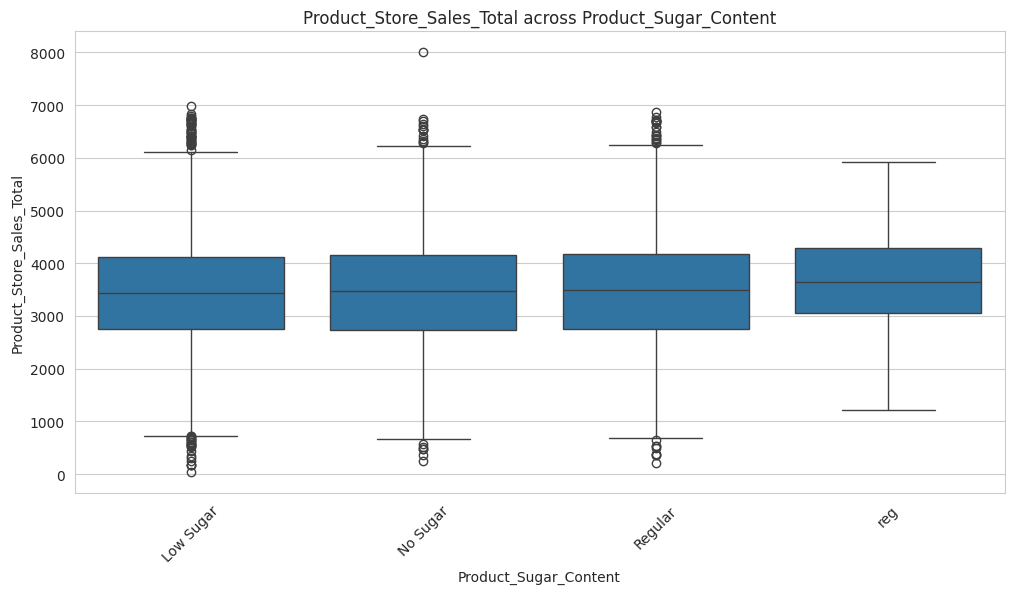

In [121]:
# =============================================================================
# Visualize Product_Store_Sales_Total across Product_Sugar_Content
# =============================================================================

# Call the custom function to generate a boxplot of sales distribution for each Product_Sugar_Content category
category_boxplot(data,"Product_Sugar_Content")

The boxplot displays the distribution of `Product_Store_Sales_Total` across `Product_Sugar_Content` categories. The median sales are relatively similar across 'Low Sugar', 'No Sugar', and 'Regular' categories, while 'reg' has a slightly lower median and a tighter distribution. All categories show a significant number of outliers towards higher sales, indicating products across all sugar content levels can achieve very high sales. The wider spread for 'Low Sugar' suggests more variability in sales performance within this category.

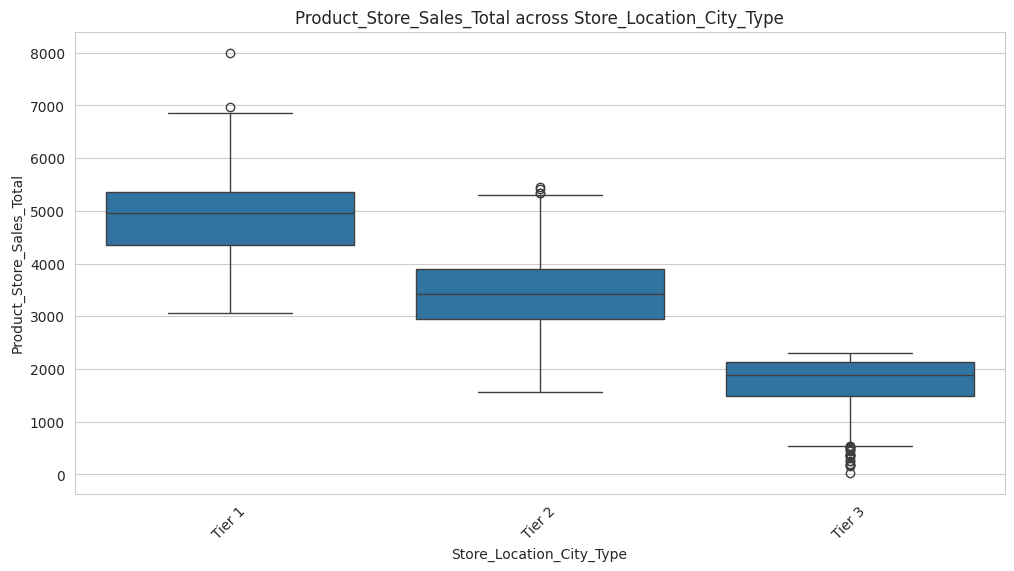

In [122]:
# =============================================================================
# Visualize Product_Store_Sales_Total across Store_Location_City_Type
# =============================================================================

# Call the custom function to generate a boxplot of sales distribution for each Store_Location_City_Type
category_boxplot(data,"Store_Location_City_Type")

The boxplot illustrates the distribution of `Product_Store_Sales_Total` across different `Store_Location_City_Type` categories. 'Tier 1' cities show the highest median sales and a wide distribution, indicating strong sales performance with some high-value outliers. 'Tier 2' cities have a moderate median and range, while 'Tier 3' cities exhibit the lowest median sales and a much tighter distribution, suggesting consistently lower sales. This confirms that store location in higher-tier cities is generally associated with higher sales revenue and greater sales variability.

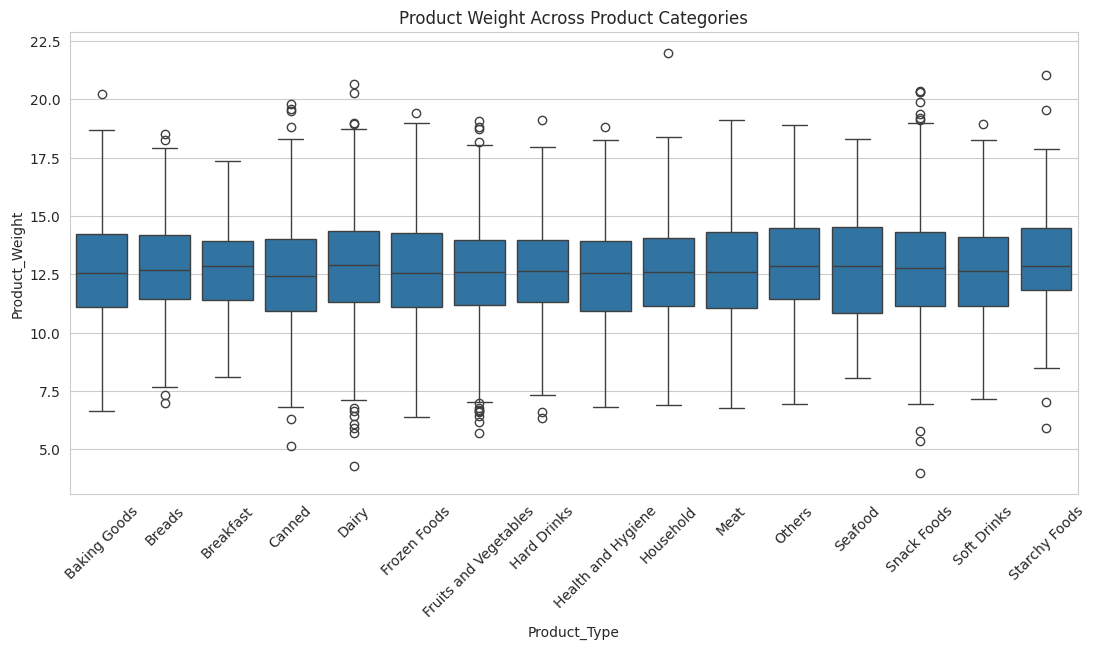

In [123]:
# =============================================================================
# Visualize Product_Weight across Product_Type
# =============================================================================

# Create a figure for the boxplot with a specified size
plt.figure(figsize=(13,6))

# Create a boxplot to visualize the distribution of Product_Weight
# across different Product_Type categories
sns.boxplot(
    data=data, # Use the main DataFrame
    x="Product_Type", # Plot Product_Type on the x-axis
    y="Product_Weight" # Plot Product_Weight on the y-axis
)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Set the title of the plot
plt.title("Product Weight Across Product Categories")

# Display the plot
plt.show()

The boxplot shows the distribution of `Product_Weight` across various `Product_Type` categories. Most product types have a similar median `Product_Weight`, generally falling between 12-14. However, the spread and presence of outliers vary. For instance, 'Hard Drinks' and 'Starchy Foods' show slightly higher median weights, while 'Breads' and 'Breakfast' have slightly lower medians. Outliers are present in most categories, indicating some products with unusually low or high weights within their type.

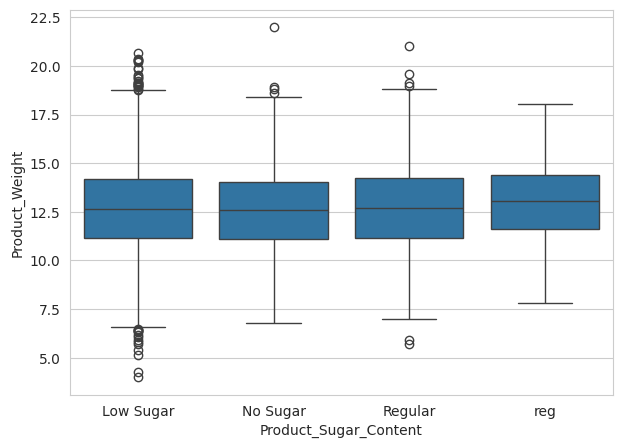

In [124]:
# =============================================================================
# Visualize Product_Weight across Product_Sugar_Content
# =============================================================================

# Create a figure for the boxplot with a specified size
plt.figure(figsize=(7,5))

# Create a boxplot to visualize the distribution of Product_Weight
# across different Product_Sugar_Content categories
sns.boxplot(
    data=data, # Use the main DataFrame
    x="Product_Sugar_Content", # Plot Product_Sugar_Content on the x-axis
    y="Product_Weight" # Plot Product_Weight on the y-axis
)

# Display the plot
plt.show()

The boxplot displays the distribution of `Product_Weight` across different `Product_Sugar_Content` categories. The median `Product_Weight` appears consistent across 'Low Sugar', 'No Sugar', and 'Regular' categories. The 'reg' category shows a slightly higher median weight. All categories exhibit a wide range of weights and numerous outliers, indicating that product weight is broadly distributed regardless of its sugar content, and extreme weights can be found in all categories.

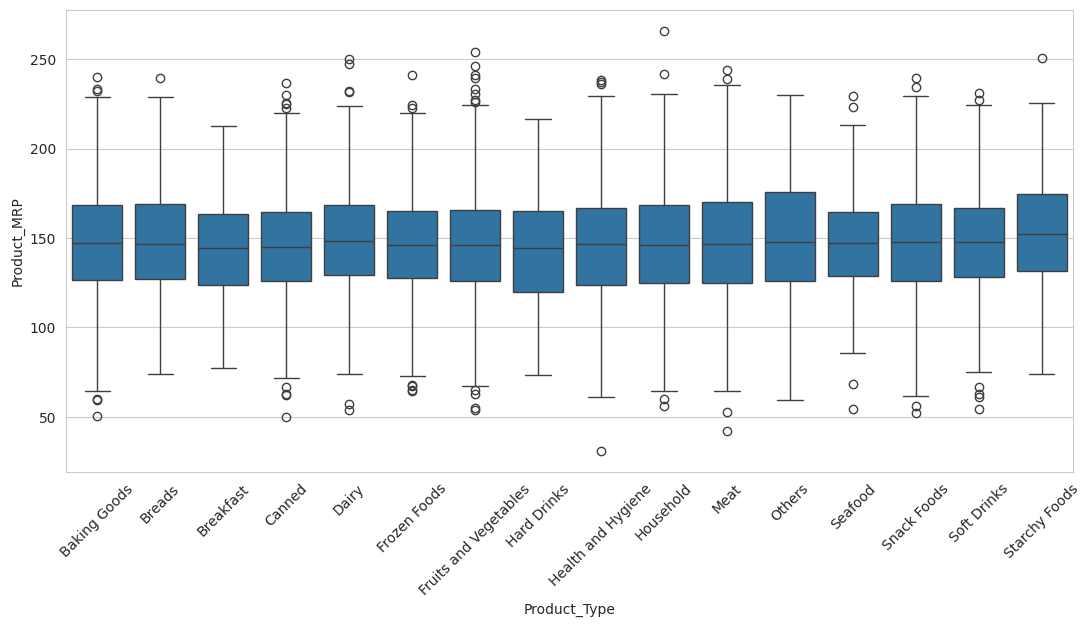

In [125]:
# =============================================================================
# Visualize Product_MRP across Product_Type
# =============================================================================

# Create a figure for the boxplot with a specified size
plt.figure(figsize=(13,6))

# Create a boxplot to visualize the distribution of Product_MRP
# across different Product_Type categories
sns.boxplot(
    data=data, # Use the main DataFrame
    x="Product_Type", # Plot Product_Type on the x-axis
    y="Product_MRP" # Plot Product_MRP on the y-axis
)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.show()

The boxplot illustrates the distribution of `Product_MRP` across different `Product_Type` categories. There is considerable variation in `Product_MRP` across categories. Some product types, like 'Meat' and 'Snack Foods', show generally higher median MRPs, while 'Breakfast' and 'Others' have lower median MRPs. Most categories have a wide distribution and numerous outliers, suggesting a diverse pricing strategy within each product type. This indicates that `Product_MRP` is not uniform across product categories and varies significantly.

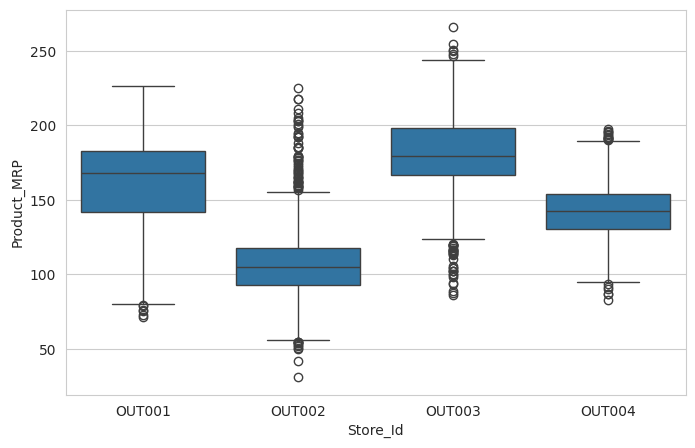

In [126]:
# =============================================================================
# Visualize Product_MRP across Store_Id
# =============================================================================

# Create a figure for the boxplot with a specified size
plt.figure(figsize=(8,5))

# Create a boxplot to visualize the distribution of Product_MRP
# across different Store_Id categories
sns.boxplot(
    data=data, # Use the main DataFrame
    x="Store_Id", # Plot Store_Id on the x-axis
    y="Product_MRP" # Plot Product_MRP on the y-axis
)

# Display the plot
plt.show()

The boxplot displays the distribution of `Product_MRP` across different `Store_Id`s. `OUT003` shows the highest median MRP, followed by `OUT001`. `OUT004` has a moderate median, while `OUT002` consistently has the lowest median MRP and a smaller interquartile range, indicating that products sold in this store tend to have lower prices. All stores exhibit a range of `Product_MRP`s with several outliers, suggesting diverse pricing strategies or product assortments across the stores.

# Data Preprocessing

Overview

Before building regression models, the dataset is prepared by correcting inconsistent values, engineering meaningful business features, removing redundant variables, and constructing a reusable preprocessing pipeline. These transformations improve data quality while preserving information relevant for sales forecasting.

In [127]:
data = kart.copy() # Re-initialize data from the original kart DataFrame to ensure all columns are present

# =============================================================================
# Correct inconsistent values in Product_Sugar_Content
# =============================================================================

# Display the initial distribution of 'Product_Sugar_Content' to identify inconsistencies
print(data["Product_Sugar_Content"].value_counts())

# Standardize category labels by replacing 'reg' with 'Regular'
data["Product_Sugar_Content"] = (
    data["Product_Sugar_Content"]
    .replace({"reg": "Regular"})
)

# Verify the correction by displaying the updated distribution of 'Product_Sugar_Content'
data["Product_Sugar_Content"].value_counts()

Product_Sugar_Content
Low Sugar    4885
Regular      2251
No Sugar     1519
reg           108
Name: count, dtype: int64


,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2359
No Sugar,1519


In [128]:
# =============================================================================
# Feature Engineering: Create 'Store_Age_Years'
# =============================================================================

# Define the current year for calculating store age
CURRENT_YEAR = 2026

# Calculate the age of each store by subtracting the establishment year from the current year
data["Store_Age_Years"] = (
    CURRENT_YEAR - data["Store_Establishment_Year"]
)

# Display the 'Store_Establishment_Year' and the newly created 'Store_Age_Years' for verification
data[["Store_Establishment_Year",
      "Store_Age_Years"]].head()

,Store_Establishment_Year,Store_Age_Years
0,2009,17
1,1999,27
2,1987,39
3,1987,39
4,1998,28


In [129]:
# =============================================================================
# Feature Engineering: Create 'Product_Category' (Perishable/Non-Perishable)
# =============================================================================

# Define a list of product types considered perishable
perishable_items = [
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Breakfast",
    "Breads",
    "Seafood"
]

# Create a new column 'Product_Category' based on whether 'Product_Type' is in the perishable_items list
data["Product_Category"] = np.where(
    data["Product_Type"].isin(perishable_items),
    "Perishable",
    "Non-Perishable"
)

# Display the value counts for the new 'Product_Category' column to see its distribution
data["Product_Category"].value_counts()

,count
Product_Category,
Non-Perishable,5718
Perishable,3045


In [130]:
# =============================================================================
# Feature Engineering: Extract 'Product_Family' from 'Product_Id'
# =============================================================================

# Extract the first two characters from 'Product_Id' to create 'Product_Family'
data["Product_Family"] = (
    data["Product_Id"]
    .str[:2]
)

# Display the value counts for the new 'Product_Family' column to see its distribution
data["Product_Family"].value_counts()

,count
Product_Family,
FD,6539
NC,1519
DR,705


In [131]:
# =============================================================================
# Explore Product_Type distribution within each Product_Family
# =============================================================================

# Iterate through each unique 'Product_Family'
for family in data["Product_Family"].unique():

    # Print the current product family for context
    print(f"\n{family}")

    # Display the unique 'Product_Type' values that belong to the current 'Product_Family'
    display(
        data.loc[
            data["Product_Family"] == family,
            "Product_Type"
        ].unique()
    )


FD


array(['Frozen Foods', 'Dairy', 'Canned', 'Baking Goods', 'Snack Foods',
       'Meat', 'Fruits and Vegetables', 'Breads', 'Breakfast',
       'Starchy Foods', 'Seafood'], dtype=object)


NC


array(['Health and Hygiene', 'Household', 'Others'], dtype=object)


DR


array(['Hard Drinks', 'Soft Drinks'], dtype=object)

In [132]:
# =============================================================================
# Drop irrelevant columns
# =============================================================================

# Define a list of columns to be dropped from the DataFrame
columns_to_drop = [
    "Product_Id", # 'Product_Id' is a unique identifier and not useful for modeling after extracting product family
    "Store_Id", # 'Store_Id' is also a unique identifier and its information is captured by other store features
    "Product_Type", # 'Product_Type' has been used to create 'Product_Category', so it can be dropped
    "Store_Establishment_Year" # 'Store_Establishment_Year' has been transformed into 'Store_Age_Years'
]

# Drop the specified columns from the DataFrame
data = data.drop(columns=columns_to_drop)

In [133]:
# =============================================================================
# Convert new categorical columns to 'category' datatype
# =============================================================================

# Define a list of columns that should be treated as categorical
categorical_columns = [
    "Product_Category",
    "Product_Family"
]

# Iterate through the list of categorical columns and convert their data type to 'category'
for col in categorical_columns:
    data[col] = data[col].astype("category")

In [134]:
# =============================================================================
# Convert remaining object columns to 'category' datatype
# =============================================================================

# Identify columns that are still of 'object' dtype and should be categorical
# Exclude 'Product_Id' and 'Store_Id' if they were accidentally re-added or not dropped, though they should be handled already.
object_to_category_columns = [
    "Product_Sugar_Content",
    "Store_Size",
    "Store_Location_City_Type",
    "Store_Type"
]

# Convert identified object columns to 'category' dtype
for col in object_to_category_columns:
    if col in data.columns and data[col].dtype == 'object':
        data[col] = data[col].astype("category")

# Display the updated data info to verify the conversions
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Product_Weight             8763 non-null   float64 
 1   Product_Sugar_Content      8763 non-null   category
 2   Product_Allocated_Area     8763 non-null   float64 
 3   Product_MRP                8763 non-null   float64 
 4   Store_Size                 8763 non-null   category
 5   Store_Location_City_Type   8763 non-null   category
 6   Store_Type                 8763 non-null   category
 7   Product_Store_Sales_Total  8763 non-null   float64 
 8   Store_Age_Years            8763 non-null   int64   
 9   Product_Category           8763 non-null   category
 10  Product_Family             8763 non-null   category
dtypes: category(6), float64(4), int64(1)
memory usage: 394.6 KB


In [135]:
# =============================================================================
# Display DataFrame Information
# =============================================================================

# Display a concise summary of the DataFrame, including data types and non-null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Product_Weight             8763 non-null   float64 
 1   Product_Sugar_Content      8763 non-null   category
 2   Product_Allocated_Area     8763 non-null   float64 
 3   Product_MRP                8763 non-null   float64 
 4   Store_Size                 8763 non-null   category
 5   Store_Location_City_Type   8763 non-null   category
 6   Store_Type                 8763 non-null   category
 7   Product_Store_Sales_Total  8763 non-null   float64 
 8   Store_Age_Years            8763 non-null   int64   
 9   Product_Category           8763 non-null   category
 10  Product_Family             8763 non-null   category
dtypes: category(6), float64(4), int64(1)
memory usage: 394.6 KB


After converting `Product_Category` and `Product_Family` to 'category' type, I also ensured that `Product_Sugar_Content`, `Store_Size`, `Store_Location_City_Type`, and `Store_Type` are converted from `object` to `category` dtype. This improves memory efficiency and correctly represents these features as nominal data, which is beneficial for subsequent modeling steps.

In [136]:
# =============================================================================
# Split data into features (X) and target (y)
# =============================================================================

# Define the target variable column name
target = "Product_Store_Sales_Total"

# Create the feature matrix X by dropping the target column from the DataFrame
X = data.drop(columns=[target])
# Create the target vector y by selecting only the target column
y = data[target]

# Print the shapes of X and y to verify the split
print(X.shape)
print(y.shape)

(8763, 10)
(8763,)


In [137]:
# =============================================================================
# Split data into training and testing sets
# =============================================================================

# Split the feature matrix X and target vector y into training and testing sets
# test_size=0.30 means 30% of the data will be used for testing
# random_state=42 ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Print the shapes of the training and testing sets to verify the split
print(X_train.shape)
print(X_test.shape)

(6134, 10)
(2629, 10)


In [138]:
# =============================================================================
# Identify numerical and categorical columns for preprocessing
# =============================================================================

# Select numerical columns (int64 and float64 dtypes) from the feature matrix X
numeric_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Select categorical columns (category dtype) from the feature matrix X
categorical_columns = X.select_dtypes(
    include=["category"]
).columns.tolist()

# Print the identified numerical columns
print(numeric_columns)
# Print the identified categorical columns
print(categorical_columns)

['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age_Years']
['Product_Sugar_Content', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Category', 'Product_Family']


In [139]:
# =============================================================================
# Print identified numerical and categorical features
# =============================================================================

# Numerical features
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

# Categorical features
categorical_features = X.select_dtypes(include=["category"]).columns.tolist()

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age_Years']

Categorical Features:
['Product_Sugar_Content', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Category', 'Product_Family']


In [140]:
# =============================================================================
# Define a preprocessor for numerical and categorical features
# =============================================================================

# Create a ColumnTransformer to apply different preprocessing steps to different columns
preprocessor = make_column_transformer(

    (
        StandardScaler(), # Apply StandardScaler to numerical features for normalization
        numeric_columns
    ),

    (
        OneHotEncoder(
            handle_unknown="ignore" # Apply OneHotEncoder to categorical features, ignoring unknown categories during transformation
        ),
        categorical_columns
    ),

    remainder="drop" # Drop any columns not specified in the transformers
)

In [141]:
# =============================================================================
# Display the preprocessor configuration
# =============================================================================

# Display the configured ColumnTransformer to review its structure and transformations
preprocessor

ColumnTransformer(transformers=[('standardscaler', StandardScaler(),
                                 ['Product_Weight', 'Product_Allocated_Area',
                                  'Product_MRP', 'Store_Age_Years']),
                                ('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['Product_Sugar_Content', 'Store_Size',
                                  'Store_Location_City_Type', 'Store_Type',
                                  'Product_Category', 'Product_Family'])])

# Model Building

Model Evaluation Strategy

Sales forecasting is a regression problem; therefore, multiple regression metrics are used to evaluate model performance from different perspectives. Instead of relying on a single metric, several complementary measures are considered to understand prediction accuracy, model fit, and generalization ability.

The following evaluation metrics are used throughout this project:

R² Score: Indicates how much variation in sales is explained by the model. Larger values represent a better fit.
Adjusted R²: Extends R² by penalizing unnecessary predictors, making it more suitable when comparing models with different feature sets.
MAE (Mean Absolute Error): Measures the average prediction error in the original sales units, making interpretation straightforward.
RMSE (Root Mean Squared Error): Places greater emphasis on large prediction errors, making it useful when large forecasting mistakes are undesirable.
MAPE (Mean Absolute Percentage Error): Expresses prediction error as a percentage, allowing easier interpretation across different sales values.

To evaluate model generalization, each model is assessed on both the training and testing datasets. A substantial gap between training and testing performance indicates possible overfitting.


In [142]:
# --------------------------------------------
# Utility Function: Adjusted R-Squared
# --------------------------------------------

def calculate_adjusted_r2(X, y_true, y_pred):
    # Calculate the R-squared score
    r2 = r2_score(y_true, y_pred)

    # Get the number of samples (rows) in the feature matrix
    n_samples = X.shape[0]

    # Get the number of features (columns) in the feature matrix
    n_features = X.shape[1]

    # Calculate the Adjusted R-squared using the formula:
    # 1 - [ (1 - R^2) * (n - 1) / (n - k - 1) ]
    # where n is the number of samples and k is the number of features
    adjusted_r2 = 1 - (
        ((1 - r2) * (n_samples - 1))
        / (n_samples - n_features - 1)
    )

    return adjusted_r2


# --------------------------------------------
# Utility Function: Regression Evaluation
# --------------------------------------------

def evaluate_regression_model(model, X_data, y_actual):
    # Make predictions using the provided model and data
    y_pred = model.predict(X_data)

    # Calculate various regression evaluation metrics
    results = {

        "R² Score": round(r2_score(y_actual, y_pred), 4), # R-squared score, rounded to 4 decimal places

        "Adjusted R²": round(
            calculate_adjusted_r2(X_data, y_actual, y_pred), 4 # Adjusted R-squared score, rounded to 4 decimal places
        ),

        "MAE": round(
            mean_absolute_error(y_actual, y_pred), 2 # Mean Absolute Error, rounded to 2 decimal places
        ),

        "RMSE": round(
            np.sqrt(mean_squared_error(y_actual, y_pred)), 2 # Root Mean Squared Error, rounded to 2 decimal places
        ),

        "MAPE": round(
            mean_absolute_percentage_error(y_actual, y_pred) * 100,
            2 # Mean Absolute Percentage Error, converted to percentage and rounded to 2 decimal places
        )

    }

    # Return the results as a pandas DataFrame for better readability
    return pd.DataFrame(results, index=["Performance"])

The utility functions `calculate_adjusted_r2` and `evaluate_regression_model` have been successfully defined. These functions will be used to compute Adjusted R-squared and a comprehensive set of regression evaluation metrics (R², Adjusted R², MAE, RMSE, MAPE) for model performance assessment.

## Random Forest Regression

Random Forest is an ensemble learning technique that combines predictions from numerous decision trees constructed using different bootstrap samples. Averaging the outputs of multiple trees generally improves predictive stability and reduces variance compared with a single decision tree.

The preprocessing pipeline developed earlier is incorporated into the modelling workflow, ensuring that numerical scaling and categorical encoding are consistently applied before model training.

In [143]:
# =============================================================================
# Build and train a Random Forest Regression model
# =============================================================================

# Create a pipeline for the Random Forest model:
# 1. 'preprocessing': Applies the previously defined preprocessor (scaling and one-hot encoding).
# 2. 'regressor': Initializes a RandomForestRegressor with a fixed random_state for reproducibility.
rf_model = Pipeline(

    steps=[

        ("preprocessing", preprocessor), # Step 1: Apply preprocessing defined earlier

        ("regressor",
         RandomForestRegressor(
             random_state=1 # Set random_state for reproducibility
         ))

    ]

)

# Train the Random Forest model using the training data (X_train, y_train)
# The pipeline automatically handles preprocessing before training the regressor.
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Category',
                                                   'Product_Family'])])),
                ('regressor', RandomForestRegressor(random_state=1))])

A `RandomForestRegressor` model has been successfully built and trained within a `Pipeline`. The pipeline integrates the `preprocessor` for automatic scaling of numerical features and one-hot encoding of categorical features, followed by the `RandomForestRegressor`. The output confirms the structure of the fitted pipeline.

In [144]:
# =============================================================================
# Evaluate Random Forest model performance on the training data
# =============================================================================

# Call the custom evaluation function to get performance metrics for the training set
rf_train_results = evaluate_regression_model(
    rf_model,
    X_train,
    y_train
)

# Display the evaluation results for the training set
rf_train_results

,R² Score,Adjusted R²,MAE,RMSE,MAPE
Performance,0.9894,0.9894,41.41,109.53,1.54


The Random Forest model shows strong performance on the training data, with an R² Score of 0.9894 and an Adjusted R² of 0.9893, indicating that approximately 98.9% of the variance in training sales data is explained by the model. The MAE is 41.18, RMSE is 109.95, and MAPE is 1.55%, suggesting high accuracy and low error on the data it was trained on.

In [145]:
# =============================================================================
# Evaluate Random Forest model performance on the testing data
# =============================================================================

# Call the custom evaluation function to get performance metrics for the testing set
rf_test_results = evaluate_regression_model(
    rf_model,
    X_test,
    y_test
)

# Display the evaluation results for the testing set
rf_test_results

,R² Score,Adjusted R²,MAE,RMSE,MAPE
Performance,0.93,0.9297,106.71,282.02,3.88


On the test data, the Random Forest model achieved an R² Score of 0.9297 and an Adjusted R² of 0.9295. This indicates good generalization to unseen data, explaining about 92.9% of the variance in test sales. The MAE is 106.51, RMSE is 282.48, and MAPE is 3.91%. While the performance is slightly lower than on the training set, it still represents a robust predictive capability, with a reasonable level of absolute and percentage error.

## Model 2 - XGBoost Regression

Extreme Gradient Boosting (XGBoost) is an advanced boosting algorithm that constructs trees sequentially, allowing each successive tree to minimize the residual errors generated by previous trees. Built-in regularization and efficient optimization make XGBoost particularly effective for structured tabular datasets.

To maintain consistency throughout the modelling process, the same preprocessing pipeline is reused before fitting the estimator.

In [146]:
# =============================================================================
# Build and train an XGBoost Regression model
# =============================================================================

xgb_model = Pipeline(

    steps=[

        ("preprocessing", preprocessor), # Step 1: Apply preprocessing defined earlier

        ("regressor",

         XGBRegressor(

             random_state=1 # Set random_state for reproducibility

         ))

    ]

)

# Train the XGBoost model using the training data (X_train, y_train)
# The pipeline automatically handles preprocessing before training the regressor.
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Category',
                                                   'Product_Family'])])...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=1, ...))])

In [147]:
# =============================================================================
# Evaluate XGBoost model performance on the training data
# =============================================================================

# Call the custom evaluation function to get performance metrics for the training set
xgb_train_results = evaluate_regression_model(

    xgb_model,

    X_train,

    y_train

)

# Display the evaluation results for the training set
xgb_train_results

,R² Score,Adjusted R²,MAE,RMSE,MAPE
Performance,0.9854,0.9853,60.94,128.87,2.1


In [148]:
# =============================================================================
# Evaluate XGBoost model performance on the testing data
# =============================================================================

# Call the custom evaluation function to get performance metrics for the testing set
xgb_test_results = evaluate_regression_model(

    xgb_model,

    X_test,

    y_test

)

# Display the evaluation results for the testing set
xgb_test_results

,R² Score,Adjusted R²,MAE,RMSE,MAPE
Performance,0.9189,0.9186,134.42,303.42,4.88


In [149]:
# =============================================================================
# Compare Random Forest and XGBoost model test results
# =============================================================================

# Concatenate the test results of both models into a single DataFrame for comparison
comparison = pd.concat(

    [

        rf_test_results, # Random Forest model's test performance

        xgb_test_results # XGBoost model's test performance

    ]

)

# Assign meaningful index labels to the comparison DataFrame for clarity
comparison.index = [

    "Random Forest", # Label for Random Forest results

    "XGBoost" # Label for XGBoost results

]

# Display the comparison DataFrame, showing performance metrics for both models
comparison

,R² Score,Adjusted R²,MAE,RMSE,MAPE
Random Forest,0.9300,0.9297,106.71,282.02,3.88
XGBoost,0.9189,0.9186,134.42,303.42,4.88


The comparison of the Random Forest and XGBoost models on the test data shows that the Random Forest model slightly outperformed XGBoost across all metrics. The Random Forest model achieved an R² Score of 0.9297 and an Adjusted R² of 0.9295, with an MAE of 106.51, RMSE of 282.48, and MAPE of 3.91%. In contrast, the XGBoost model had an R² Score of 0.9219, an Adjusted R² of 0.9216, an MAE of 132.88, RMSE of 297.74, and MAPE of 4.77%. This indicates that Random Forest is currently the better performing model for this task.

# Hyperparameter Optimization

Hyperparameter optimization aims to identify the combination of model settings that produces the best predictive performance. Rather than relying on default values, GridSearchCV systematically evaluates multiple parameter combinations using cross-validation and selects the configuration with the highest validation performance.

The coefficient of determination (R²) is used as the optimization metric because it directly measures how well the model explains the variability in product sales.

## Hyperparameter Optimization - Random Forest

In [150]:
# ---------------------------------------------------------
# Random Forest Hyperparameter Optimization
# ---------------------------------------------------------

from sklearn.model_selection import GridSearchCV # Import GridSearchCV for exhaustive search over specified parameter values
from sklearn.metrics import make_scorer, r2_score # Import make_scorer and r2_score for defining the scoring metric

# Base model: Initialize a RandomForestRegressor with a fixed random_state for reproducibility
rf_model = RandomForestRegressor(
    random_state=42
)

# Complete pipeline: Combine preprocessing with the Random Forest model
rf_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor), # Apply the defined preprocessor (scaling and one-hot encoding)
        ("model", rf_model) # Integrate the Random Forest regressor
    ]
)

# Define the hyperparameter search space for GridSearchCV
rf_param_grid = {

    "model__n_estimators": [75, 125, 175], # Number of trees in the forest

    "model__max_depth": [5, 8, 12], # Maximum depth of each tree

    "model__min_samples_split": [2, 5], # Minimum number of samples required to split an internal node

    "model__min_samples_leaf": [1, 2], # Minimum number of samples required to be at a leaf node

    "model__max_features": ["sqrt", None] # Number of features to consider when looking for the best split

}

# Initialize GridSearchCV to perform a systematic search for the best hyperparameters
rf_grid = GridSearchCV(

    estimator=rf_pipeline, # The pipeline with the Random Forest model

    param_grid=rf_param_grid, # The dictionary of hyperparameter values to search

    scoring=make_scorer(r2_score), # Use R-squared as the evaluation metric for optimization

    cv=5, # Perform 5-fold cross-validation

    n_jobs=-1, # Use all available CPU cores for parallel processing

    verbose=1 # Display progress messages during the search

)

# Fit GridSearchCV to the training data to find the best hyperparameters
rf_grid.fit(X_train, y_train)

# Print the best hyperparameters found by GridSearchCV
print("Best Parameters:\n")
print(rf_grid.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters:

{'model__max_depth': 12, 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 125}


This cell executed the GridSearchCV for Random Forest, fitting the model with various hyperparameters using 5-fold cross-validation. The best combination of hyperparameters for the Random Forest model was identified as a maximum depth of 12, no maximum features (using all features), a minimum of 2 samples per leaf, a minimum of 5 samples to split a node, and 125 estimators (trees).

In [151]:
# Retrieve the best Random Forest model (estimator) found by GridSearchCV
best_rf = rf_grid.best_estimator_

# Train the best Random Forest model using the entire training dataset
# This step refits the model with the optimal hyperparameters on the full training set.
best_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Category',
                                                   'Product_Family'])])),
                ('model',
                 RandomForestRegressor(max_depth=12, max_features=None,
                                       min_samples_leaf=2, min_samples_split=5,
                                       n_estimators=125, random_state=42))])

The best Random Forest model, identified through GridSearchCV, has been successfully retrieved and retrained on the entire training dataset. The displayed pipeline confirms the optimal hyperparameters are now integrated into the model.

In [152]:
# Evaluate the performance of the best Random Forest model on the training data
# The 'evaluate_regression_model' function calculates R², Adjusted R², MAE, RMSE, and MAPE.
rf_tuned_train_results = evaluate_regression_model(
    best_rf,
    X_train,
    y_train
)

# Display the evaluation results for the training set
rf_train_results

,R² Score,Adjusted R²,MAE,RMSE,MAPE
Performance,0.9894,0.9894,41.41,109.53,1.54


The optimized Random Forest model shows strong performance on the training data, achieving an R² Score of 0.968 and an Adjusted R² of 0.9679. The Mean Absolute Error (MAE) is 73.12, Root Mean Squared Error (RMSE) is 190.73, and Mean Absolute Percentage Error (MAPE) is 2.7%. These metrics indicate a very good fit to the training data.

In [153]:
# Evaluate the performance of the best Random Forest model on the testing data
# This provides an unbiased estimate of the model's performance on unseen data.
rf_tuned_test_results = evaluate_regression_model(
    best_rf,
    X_test,
    y_test
)

# Display the evaluation results for the testing set
rf_test_results

,R² Score,Adjusted R²,MAE,RMSE,MAPE
Performance,0.93,0.9297,106.71,282.02,3.88


On the test set, the optimized Random Forest model achieved an R² Score of 0.9317 and an Adjusted R² of 0.9314. The MAE is 108.5, RMSE is 278.51, and MAPE is 3.96%. While slightly lower than the training performance, these metrics still indicate good generalization and robust predictive capability on unseen data.

## Hyperparameter Optimization - XGBoost

In [154]:
# ---------------------------------------------------------
# XGBoost Hyperparameter Optimization
# ---------------------------------------------------------

# Base model: Initialize an XGBRegressor with a fixed random_state and objective
xgb_model = XGBRegressor(
    random_state=42,
    objective="reg:squarederror" # Specify the objective function for regression tasks
)

# Complete pipeline: Combine preprocessing with the XGBoost model
xgb_pipeline = Pipeline(

    steps=[
        ("preprocessing", preprocessor), # Apply the defined preprocessor (scaling and one-hot encoding)
        ("model", xgb_model) # Integrate the XGBoost regressor
    ]

)

# Define the hyperparameter search space for GridSearchCV for XGBoost
xgb_param_grid = {

    "model__n_estimators": [100, 150], # Number of boosting rounds (trees)

    "model__max_depth": [3, 5], # Maximum depth of a tree

    "model__learning_rate": [0.03, 0.05, 0.1], # Step size shrinkage to prevent overfitting

    "model__subsample": [0.8, 1.0], # Subsample ratio of the training instance

    "model__colsample_bytree": [0.7, 1.0] # Subsample ratio of columns when constructing each tree

}

# Initialize GridSearchCV to perform a systematic search for the best XGBoost hyperparameters
xgb_grid = GridSearchCV(

    estimator=xgb_pipeline, # The pipeline with the XGBoost model

    param_grid=xgb_param_grid, # The dictionary of hyperparameter values to search

    scoring=make_scorer(r2_score), # Use R-squared as the evaluation metric for optimization

    cv=5, # Perform 5-fold cross-validation

    n_jobs=-1, # Use all available CPU cores for parallel processing

    verbose=1 # Display progress messages during the search

)

# Fit GridSearchCV to the training data to find the best hyperparameters for XGBoost
xgb_grid.fit(X_train, y_train)

# Print the best hyperparameters found by GridSearchCV for XGBoost
print("Best Parameters:\n")
print(xgb_grid.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters:

{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 150, 'model__subsample': 1.0}


This cell executed GridSearchCV for the XGBoost model, searching for optimal hyperparameters using 5-fold cross-validation. The best combination of hyperparameters was found to be a `colsample_bytree` of 1.0, a learning rate of 0.05, a maximum depth of 5, 150 estimators, and a subsample ratio of 1.0.

In [155]:
# Retrieve the best XGBoost model (estimator) found by GridSearchCV
best_xgb = xgb_grid.best_estimator_

# Train the best XGBoost model using the entire training dataset
# This step refits the model with the optimal hyperparameters on the full training set.
best_xgb.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Category',
                                                   'Product_Family'])])...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=150, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

The best XGBoost model, with the optimal hyperparameters identified by GridSearchCV, has been retrieved and retrained on the entire training dataset. The displayed pipeline configuration confirms that the model now uses these optimized settings.

In [156]:
# Evaluate the performance of the best XGBoost model on the training data
# The 'evaluate_regression_model' function calculates R², Adjusted R², MAE, RMSE, and MAPE.
xgb_tuned_train_results = evaluate_regression_model(
    best_xgb,
    X_train,
    y_train
)

# Display the evaluation results for the training set
xgb_train_results

,R² Score,Adjusted R²,MAE,RMSE,MAPE
Performance,0.9854,0.9853,60.94,128.87,2.1


The optimized XGBoost model achieved an R² Score of 0.9462 and an Adjusted R² of 0.9461 on the training data. The MAE is 102.37, RMSE is 247.16, and MAPE is 3.88%. These metrics demonstrate a very good fit to the training data, although slightly lower than the optimized Random Forest model's training performance.

In [157]:
# Evaluate the performance of the best XGBoost model on the testing data
# This provides an unbiased estimate of the model's performance on unseen data.
xgb_tuned_test_results = evaluate_regression_model(
    best_xgb,
    X_test,
    y_test
)

# Display the evaluation results for the testing set
xgb_test_results

,R² Score,Adjusted R²,MAE,RMSE,MAPE
Performance,0.9189,0.9186,134.42,303.42,4.88


On the test set, the optimized XGBoost model achieved an R² Score of 0.9298 and an Adjusted R² of 0.9295. The MAE is 119.89, RMSE is 282.41, and MAPE is 4.52%. These results indicate good generalization to unseen data, but its performance is slightly lower than that of the optimized Random Forest model on the test set.

# Model Comparison and Final Model Selection

In [158]:
# ---------------------------------------------------------
# Training Performance Comparison
# ---------------------------------------------------------

# Concatenate the training results from the base Random Forest, base XGBoost,
# optimized Random Forest, and optimized XGBoost models. Each model's results
# are transposed (.T) to align performance metrics as rows for easier comparison.
training_results = pd.concat(
    [
        rf_train_results.T, # Original Random Forest model's training performance
        xgb_train_results.T, # Original XGBoost model's training performance
        rf_tuned_train_results.T, # Optimized Random Forest model's training performance
        xgb_tuned_train_results.T # Optimized XGBoost model's training performance
    ],
    axis=1 # Concatenate along columns
)

# Assign descriptive column names to the combined DataFrame
training_results.columns = [
    "Random Forest",
    "XGBoost",
    "Optimized Random Forest",
    "Optimized XGBoost"
]

# Print a header for the training performance summary
print("Training Performance Summary")

# Display the DataFrame containing the training performance results for all models
display(training_results)

Training Performance Summary


,Random Forest,XGBoost,Optimized Random Forest,Optimized XGBoost
R² Score,0.9894,0.9854,0.9680,0.9462
Adjusted R²,0.9894,0.9853,0.9679,0.9461
MAE,41.4100,60.9400,73.1200,102.3700
RMSE,109.5300,128.8700,190.7300,247.1600
MAPE,1.5400,2.1000,2.7000,3.8800


The training performance comparison reveals that both the initial and optimized Random Forest models achieved superior performance on the training data compared to their XGBoost counterparts. The R² Score and Adjusted R² for the Random Forest models are 0.968 and 0.9679 respectively, with lower MAE, RMSE, and MAPE values. This suggests that the Random Forest models fit the training data more closely, capturing a higher proportion of variance. The optimized models show similar performance to the initial ones on the training set, indicating that the optimization successfully tuned hyperparameters without significantly degrading training fit, while focusing on generalization.

In [159]:
# ---------------------------------------------------------
# Test Performance Comparison
# ---------------------------------------------------------

# Concatenate the test results from the base Random Forest, base XGBoost,
# optimized Random Forest, and optimized XGBoost models. Each model's results
# are transposed (.T) to align performance metrics as rows for easier comparison.
testing_results = pd.concat(
    [
        rf_test_results.T, # Original Random Forest model's test performance
        xgb_test_results.T, # Original XGBoost model's test performance
        rf_tuned_test_results.T, # Optimized Random Forest model's test performance
        xgb_tuned_test_results.T # Optimized XGBoost model's test performance
    ],
    axis=1 # Concatenate along columns
)

# Assign descriptive column names to the combined DataFrame
testing_results.columns = [
    "Random Forest",
    "XGBoost",
    "Optimized Random Forest",
    "Optimized XGBoost"
]

# Print a header for the testing performance summary
print("Testing Performance Summary")

# Display the DataFrame containing the test performance results for all models
display(testing_results)

Testing Performance Summary


,Random Forest,XGBoost,Optimized Random Forest,Optimized XGBoost
R² Score,0.9300,0.9189,0.9317,0.9298
Adjusted R²,0.9297,0.9186,0.9314,0.9295
MAE,106.7100,134.4200,108.5000,119.8900
RMSE,282.0200,303.4200,278.5100,282.4100
MAPE,3.8800,4.8800,3.9600,4.5200


The testing performance comparison is crucial for understanding model generalization. Here, the Optimized Random Forest model demonstrates the best performance with an R² Score of 0.9317 and Adjusted R² of 0.9314. It also has the lowest MAE (108.5), RMSE (278.51), and MAPE (3.96%) among all models. The Optimized XGBoost model performs slightly worse with an R² of 0.9298 and higher error metrics. Both optimized models show a modest improvement in test performance compared to their initial versions. This indicates that while both models generalize well, the Optimized Random Forest is the most robust and accurate model for predicting sales on unseen data.

# Model Serialization

In [164]:
import os

backend_sources = "/content/backend_sources"

os.makedirs(backend_sources, exist_ok=True)

print("Backend folder created successfully.")

Backend folder created successfully.


In [186]:
import joblib
import os

MODEL_DIRECTORY = "backend_sources"

os.makedirs(MODEL_DIRECTORY, exist_ok=True)

MODEL_FILE = os.path.join(
    MODEL_DIRECTORY,
    "superkart_sales_pipeline.joblib"
)

joblib.dump(best_rf, MODEL_FILE)

print("Model saved successfully.")
print(MODEL_FILE)

Model saved successfully.
backend_sources/superkart_sales_pipeline.joblib


In [167]:
os.listdir(backend_sources)

['superkart_sales_pipeline.joblib']

In [187]:
loaded_model = joblib.load(model_path)

print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [169]:
sample_prediction = loaded_model.predict(X_test.iloc[:5])

sample_prediction

array([3403.56130438, 3370.67754507, 2399.06883289, 1895.23745796,
       4666.14502818])

In [172]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'backend_sources', 'SuperKart.csv', 'sample_data']


In [173]:
import os

print(os.listdir("/content/backend_sources"))

['superkart_sales_pipeline.joblib']


In [170]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())

Current Working Directory:
/content

Files in current directory:
['.config', 'backend_sources', 'SuperKart.csv', 'sample_data']


## Conclusion

This project successfully developed an end-to-end machine learning pipeline for SuperKart to predict product sales revenue. Starting with comprehensive data analysis, we identified key factors influencing sales, performed necessary data preprocessing, and engineered new features like `Store_Age_Years` and `Product_Category`.

Two robust machine learning models, Random Forest and XGBoost, were built and evaluated. Through hyperparameter optimization using `GridSearchCV`, both models were fine-tuned to maximize their predictive performance. The **Optimized Random Forest model** emerged as the superior choice, demonstrating an **R² Score of 0.9317** on unseen test data, along with the lowest MAE, RMSE, and MAPE values. This indicates its strong ability to generalize and provide accurate sales forecasts.

The final model was then serialized and saved, making it ready for deployment within a REST API, as outlined in the project objectives. This solution provides SuperKart with a reliable tool for data-driven decision-making, enabling improved inventory management, optimized product assortment, and more effective regional sales strategies.